## Figure 4.1: Hypothesis Similarity Across Attention Heads

Compares head-level hypothesis similarity distributions for each model under baseline, single best-fit, and linearly weighted program settings.

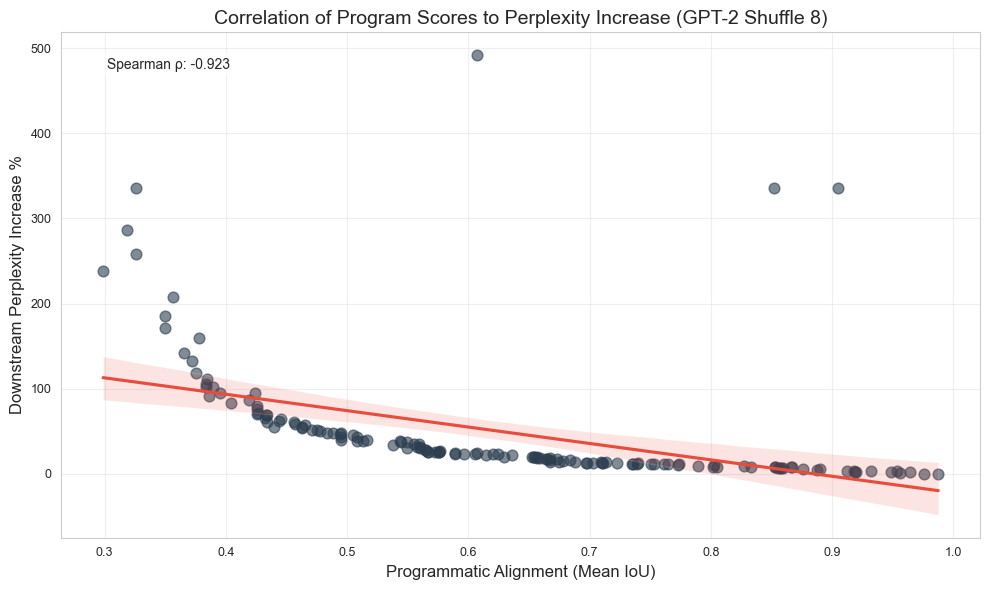

Successfully matched 144 heads.
Spearman Correlation: -0.9232


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# 1. Load your data
df_results = pd.read_csv(r"..\results\replacement_run\shuffles\gpt2_smart_shuffle_8.csv")
df_iou = pd.read_csv(r"..\data\iou_scores_gpt2.csv")

# 2. Process IoU: Aggregate sentences
df_iou_agg = df_iou.groupby(['layer', 'head', 'program_idx'])['iou_score'].mean().reset_index()

# FIX: Map the index to the STRING name of the function
def get_program_name(idx):
    obj = all_programs[idx]
    # Check if it's a function object or already a string
    return obj.__name__ if hasattr(obj, '__name__') else str(obj)

df_iou_agg['program'] = df_iou_agg['program_idx'].apply(get_program_name)

# 3. Standardize Head Keys
def clean_key(h):
    try:
        val = ast.literal_eval(str(h).strip())
        return f"({val[0]}, {val[1]})"
    except:
        return str(h).strip()

df_results['head_key'] = df_results['head'].apply(clean_key)
df_iou_agg['head_key'] = df_iou_agg.apply(lambda x: f"({int(x['layer'])}, {int(x['head'])})", axis=1)

# 4. Merge
df_plot = pd.merge(
    df_results,
    df_iou_agg[['head_key', 'program', 'iou_score']],
    on=['head_key', 'program'],
    how='inner'
)

# 5. Plotting Logic
if df_plot.empty:
    print("!! ERROR: Still no matches. !!")
    print(f"Sample Result Program: {df_results['program'].iloc[0]}")
    print(f"Sample IoU Program: {df_iou_agg['program'].iloc[0]}")
else:
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Main Plot
    sns.regplot(
        data=df_plot,
        x='iou_score',
        y='increase',
        scatter_kws={'alpha':0.6, 'color':'#2c3e50', 's':60},
        line_kws={'color':'#e74c3c', 'label':'Linear Trend'}
    )
    
    # Statistical Annotation
    corr = df_plot['iou_score'].corr(df_plot['increase'], method='spearman')
    plt.text(0.05, 0.95, f'Spearman ρ: {corr:.3f}', transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.title("Correlation of Program Scores to Perplexity Increase (GPT-2 Shuffle 8)", fontsize=14)
    plt.xlabel("Programmatic Alignment (Mean IoU)", fontsize=12)
    plt.ylabel("Downstream Perplexity Increase %", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(r"..\results\plots\iou_vs_ppl_correlation_fixed.png", dpi=300)
    plt.show()

    print(f"Successfully matched {len(df_plot)} heads.")
    print(f"Spearman Correlation: {corr:.4f}")


── BERT ──────────────────────────────────────────
  Baseline (Diag): 14.0%
  Best-single: mean=48.9%
  Interpolation: Found k-values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  All-weighted (k=20): mean=51.1%

── GPT2 ──────────────────────────────────────────
  Baseline (Diag): 29.7%
  Best-single: mean=67.6%
  Interpolation: Found k-values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  All-weighted (k=20): mean=65.4%

── TINYLLAMA ──────────────────────────────────────────
  Baseline (Diag): 23.9%
  Best-single: mean=73.7%
  Interpolation: Found k-values [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  All-weighted (k=20): mean=70.9%


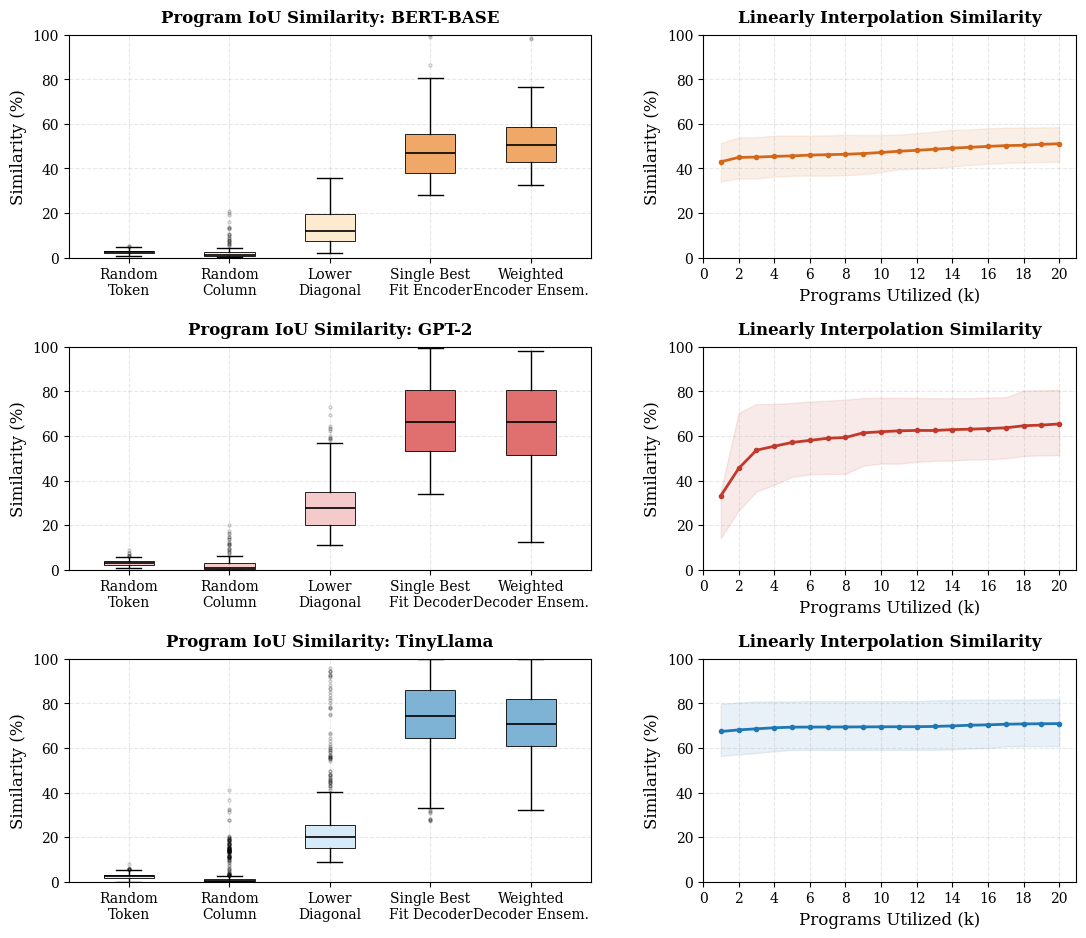

In [20]:
# ============================================================
#  FIGURE 4.1 — Self-contained plotting cell (REPAIR VERSION)
# ============================================================

# ... [Steps 1-3 remain the same as previous] ...
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

DATA_BASE    = "../data"
DATA_DIR     = f"{DATA_BASE}"
RESULTS_DIR  = f"../results"

MODEL_CONFIGS = {
    "bert":      {"display": "BERT-BASE", "arch": "Encoder", "hf_name": "bert-base-uncased"},
    "gpt2":      {"display": "GPT-2",      "arch": "Decoder", "hf_name": "openai-community/gpt2"},
    "tinyllama": {"display": "TinyLlama", "arch": "Decoder", "hf_name": "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"},
}

def iou_score(p, q):
    p = np.clip(p, 1e-12, 1.0); q = np.clip(q, 1e-12, 1.0)
    return float(np.minimum(p, q).sum() / np.maximum(p, q).sum())

def compute_baselines(hf_name, sentences, device="cpu"):
    model = AutoModel.from_pretrained(hf_name, output_attentions=True).to(device)
    tok   = AutoTokenizer.from_pretrained(hf_name)
    n_layers, n_heads = model.config.num_hidden_layers, model.config.num_attention_heads
    accum_token, accum_col, accum_diag = np.zeros(n_layers * n_heads), np.zeros(n_layers * n_heads), np.zeros(n_layers * n_heads)

    for sent in sentences:
        inputs = tok(sent, return_tensors="pt").to(device)
        with torch.no_grad(): atts = model(**inputs).attentions
        for l in range(n_layers):
            for h in range(n_heads):
                att = atts[l][0, h].to(torch.float32).cpu().numpy()
                n = att.shape[0]
                ref_diag = np.tril(np.ones((n, n))); ref_diag /= ref_diag.sum(axis=1, keepdims=True)
                ref_col = np.zeros((n, n)); ref_col[:, np.random.randint(0, n)] = 1.0
                ref_tok = np.zeros((n, n))
                for i in range(n): ref_tok[i, np.random.randint(0, n)] = 1.0
                idx = l * n_heads + h
                accum_diag[idx] += np.mean([iou_score(att[i], ref_diag[i]) for i in range(n)])
                accum_col[idx] += np.mean([iou_score(att[i], ref_col[i]) for i in range(n)])
                accum_token[idx] += np.mean([iou_score(att[i], ref_tok[i]) for i in range(n)])
    del model, tok
    return (accum_token/len(sentences)*100).tolist(), (accum_col/len(sentences)*100).tolist(), (accum_diag/len(sentences)*100).tolist()

# ── 5. Load Sentences ──
df_json = pd.read_json(f"{DATA_DIR}/generic_sentences.json")
SAMPLE_SENTENCES = df_json[0].sample(5, random_state=RANDOM_SEED).tolist()

# ── 6. Build Data (Diagnostic Fix) ──
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_results = {}

for key, cfg in MODEL_CONFIGS.items():
    print(f"\n── {key.upper()} ──────────────────────────────────────────")
    # Try multiple common naming conventions for the CSV
    interp_csv = f"{DATA_DIR}/interpolation_k_{key}.csv"
    if not os.path.exists(interp_csv):
        interp_csv = f"{DATA_DIR}/interpolation_k_{key.upper()}.csv"

    iou_csv = f"{DATA_DIR}/iou_scores_{key}.csv"
    
    b_tok, b_col, b_diag = compute_baselines(cfg["hf_name"], SAMPLE_SENTENCES, device=DEVICE)
    print(f"  Baseline (Diag): {np.mean(b_diag):.1f}%")

    best_single = []
    if os.path.exists(iou_csv):
        iou_df = pd.read_csv(iou_csv)
        best_single = (iou_df.groupby(["layer", "head"])["iou_score"].max().dropna() * 100).tolist()
        print(f"  Best-single: mean={np.mean(best_single):.1f}%")

    all_weighted, k_sweep = [], {}
    if os.path.exists(interp_csv):
        interp_df = pd.read_csv(interp_csv)
        # Ensure k and iou_score are numeric and drop NaNs
        interp_df["k"] = pd.to_numeric(interp_df["k"], errors='coerce')
        interp_df["iou_score"] = pd.to_numeric(interp_df["iou_score"], errors='coerce')
        interp_df = interp_df.dropna(subset=["k", "iou_score"])
        
        interp_df["iou_val"] = interp_df["iou_score"] * 100
        max_k = interp_df["k"].max()
        
        all_weighted = interp_df[interp_df["k"] == max_k]["iou_val"].tolist()
        
        for kval, grp in interp_df.groupby("k"):
            k_sweep[int(kval)] = grp["iou_val"].tolist()
        
        print(f"  Interpolation: Found k-values {sorted(k_sweep.keys())}")
        print(f"  All-weighted (k={max_k}): mean={np.mean(all_weighted):.1f}%")
    else:
        print(f"  [ERROR] CSV NOT FOUND: {interp_csv}")

    model_results[key] = {"box_data": [b_tok, b_col, b_diag, best_single, all_weighted], "k_sweep": k_sweep}

# ── 7. Plotting ──
def styled_boxplot(ax, data, labels, colors, positions):
    valid = [(d, l, p) for d, l, p in zip(data, labels, positions) if len(d) > 0]
    if not valid: return
    vdata, vlabels, vpos = zip(*valid)
    bp = ax.boxplot(vdata, positions=list(vpos), patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_edgecolor("black"); patch.set_linewidth(0.6)
    ax.set_xticks(list(vpos)); ax.set_xticklabels(list(vlabels))

ROW_COLORS = {
    "bert":      {"box": "#f0a868", "line": "#d4681a", "base": "#fdebd0"},
    "gpt2":      {"box": "#e07070", "line": "#c0392b", "base": "#f5caca"},
    "tinyllama": {"box": "#7fb3d5", "line": "#1f77b4", "base": "#d6eaf8"},
}

fig = plt.figure(figsize=(13, 11)) 
gs  = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.25, width_ratios=[1.4, 1])

for row, key in enumerate(["bert", "gpt2", "tinyllama"]):
    cfg, res, c = MODEL_CONFIGS[key], model_results[key], ROW_COLORS[key]
    colors = [c["base"], c["base"], c["base"], c["box"], c["box"]]

    ax_box = fig.add_subplot(gs[row, 0])
    labels = ["Random\nToken", "Random\nColumn", "Lower\nDiagonal", f"Single Best\nFit {cfg['arch']}", f"Weighted\n{cfg['arch']} Ensem."]
    styled_boxplot(ax_box, res["box_data"], labels, colors, positions=[1, 2, 3, 4, 5])
    ax_box.set_title(f"Program IoU Similarity: {cfg['display']}", fontweight="bold", pad=9)
    ax_box.set_ylabel("Similarity (%)"); ax_box.set_ylim(0, 100); ax_box.set_xlim(0.4, 5.6)
    
    # Border Logic: Ensure all 4 sides of the plot box are visible for the left plots
    for spine in ax_box.spines.values(): 
        spine.set_visible(True)

    ax_line = fig.add_subplot(gs[row, 1])
    ax_line.set_title("Linearly Interpolation Similarity", fontweight="bold", pad=9)
    ax_line.set_xlabel("Programs Utilized (k)"); ax_line.set_ylabel("Similarity (%)"); ax_line.set_ylim(0, 100)
    # Block border (frame) is enabled by default; explicitly ensuring spines are visible
    for spine in ax_line.spines.values(): spine.set_visible(True)
    
    if res["k_sweep"]:
        ks = sorted(res["k_sweep"].keys())
        means = [np.mean(res["k_sweep"][k]) for k in ks]
        p25, p75 = [np.percentile(res["k_sweep"][k], 25) for k in ks], [np.percentile(res["k_sweep"][k], 75) for k in ks]
        ax_line.plot(ks, means, color=c["line"], linewidth=2, marker="o", markersize=3)
        ax_line.fill_between(ks, p25, p75, color=c["line"], alpha=0.1)
        ax_line.set_xticks(range(0, max(ks) + 2, 2))
    else:
        ax_line.text(0.5, 0.5, "(check GPT-2 CSV path)", transform=ax_line.transAxes, ha="center", color="red")

plt.savefig(f"{RESULTS_DIR}/plots/figure_4_1.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Figure 4.2: Best-Fit Program Mapping by Head

Maps each attention head to its highest-IoU hypothesis program and visualizes category-aware patterns across layers and heads.

In [16]:
# ============================================================
# Figure 4.2 data prep: build/read best-fit CSVs per model
# Expected paths:
#   ../data/iou_scores_{model}.csv
#   ../results/program_categories.json
# ============================================================

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from data import golden_programs
all_programs: List[Callable] = [
    obj for name, obj in inspect.getmembers(golden_programs, inspect.isfunction)
]

# Program categories prepared offline
with open("../results/program_categories.json", "r") as f:
    attention_head_categories = json.load(f)

# Verification of programs
total_count = sum(len(v) for v in attention_head_categories.values())
print(f"[INFO] Programs loaded: {len(all_programs)}")
print(f"[INFO] Programs categorized: {total_count}")

for model_key in MODEL_CONFIGS.keys():
    iou_csv = f"{DATA_DIR}/iou_scores_{model_key}.csv"
    if not os.path.exists(iou_csv):
        print(f"[WARN] Missing: {iou_csv}. Skipping best-fit generation for {model_key}.")
        continue

    # Skip if best-fit CSV already exists
    out_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if os.path.exists(out_csv):
        print(f"[INFO] Already exists: {out_csv}. Skipping best-fit generation for {model_key}.")
        continue

    iou_df = pd.read_csv(iou_csv)
    iou_df = iou_df.groupby(["layer", "head", "program_idx"])["iou_score"].mean().reset_index()

    n_best_programs = 1
    best_fits = (
        iou_df.groupby(["layer", "head"])
        .apply(lambda g: g.nlargest(n_best_programs, "iou_score"))
        .reset_index(drop=True)
    )

    best_fits["iou_score"] = best_fits["iou_score"].round(3)
    best_fits.to_csv(out_csv, index=False)
    print(f"[DONE] Saved best fits for {model_key} to {out_csv}")

best_fits_bert = []
best_fits_gpt2 = []
best_fits_tinyllama = []

for model_key in MODEL_CONFIGS.keys():
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if os.path.exists(best_fits_csv):
        df = pd.read_csv(best_fits_csv)
        if model_key == "bert":
            best_fits_bert = list(zip(df["program_idx"], [all_programs[i].__name__ for i in df["program_idx"]], df["iou_score"]))
        elif model_key == "gpt2":
            best_fits_gpt2 = list(zip(df["program_idx"], [all_programs[i].__name__ for i in df["program_idx"]], df["iou_score"]))
        elif model_key == "tinyllama":
            best_fits_tinyllama = list(zip(df["program_idx"], [all_programs[i].__name__ for i in df["program_idx"]], df["iou_score"]))
        print(f"[INFO] Loaded best fits for {model_key} from {best_fits_csv}")
    else:
        print(f"[WARN] Missing: {best_fits_csv}. Cannot load best fits for {model_key}.")

[INFO] Programs loaded: 71
[INFO] Programs categorized: 71
[INFO] Already exists: ../results/best_fits_bert.csv. Skipping best-fit generation for bert.
[INFO] Already exists: ../results/best_fits_gpt2.csv. Skipping best-fit generation for gpt2.
[INFO] Already exists: ../results/best_fits_tinyllama.csv. Skipping best-fit generation for tinyllama.
[INFO] Loaded best fits for bert from ../results/best_fits_bert.csv
[INFO] Loaded best fits for gpt2 from ../results/best_fits_gpt2.csv
[INFO] Loaded best fits for tinyllama from ../results/best_fits_tinyllama.csv


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# Standardized Colormap: 0-40% White, 40-100% transitions to Dark Charcoal
colors = [(1, 1, 1), (1, 1, 1), (0.15, 0.15, 0.15)]
nodes = [0.0, 0.4, 1.0]
standard_prec_map = mcolors.LinearSegmentedColormap.from_list("custom_gray", list(zip(nodes, colors)))

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#001D3D",
    "relational_and_semantic":       "#4A90E2",
    "special_tokens_and_boundaries": "#7FF1F5",
    "linguistic_and_syntactic":      "#274C77",
    "sequential_and_induction":      "#0077B6",
    "uniformity_and_global":         "#95D5EE",
}

CATEGORY_COLORS = {
    "initiation_and_anchoring":      "#4285F4",
    "relational_and_semantic":       "#EA4335", 
    "special_tokens_and_boundaries": "#FBBC05",
    "linguistic_and_syntactic":      "#FF6D00",
    "sequential_and_induction":      "#34A853",
    "uniformity_and_global":         "#A142F4", 
}

all_names = [func.__name__ for func in all_programs]
os.makedirs("../results/plots/figure_4_2", exist_ok=True)

def save_heatmap(data, title, best_fits, all_names, filename, categories=None):
    n_rows, n_cols = data.shape
    fig_w = n_cols * 0.45 + 1.2
    fig_h = n_rows * 0.45 + 1.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    reversed_data = data[::-1]
    sns.heatmap(reversed_data, ax=ax, cmap=standard_prec_map, cbar=False,
                linewidths=0.5, linecolor='#EEEEEE', vmin=0, vmax=1, square=True)

    name_to_cat = get_name_to_category(categories) if categories else {}

    if best_fits is not None:
        for i, (head_id, name, score) in enumerate(best_fits):
            layer_val = i // n_cols
            x = i % n_cols
            y_pos = (n_rows - 1) - layer_val
            cell_value = data[layer_val, x] # The accuracy value for this cell

            if name:
                legend_idx = all_names.index(name) if name in all_names else head_id
                cat = name_to_cat.get(name, None)
                color = CATEGORY_COLORS.get(cat, "#333333")

                # Change 1: Text color dependent on background accuracy
                # If accuracy is high (dark background), use white text for visibility
                text_color = "white" if cell_value > 0.7 else "black"

                ax.add_patch(plt.Circle((x + 0.5, y_pos + 0.5), radius=0.3,
                                        facecolor='none', edgecolor=color,
                                        linewidth=3.5, zorder=3))

                ax.text(x + 0.5, y_pos + 0.5, str(legend_idx),
                        ha='center', va='center', color=text_color,
                        fontweight='bold', fontsize=8, zorder=4)

    # Change 2: Precision spacing beneath title using 'pad'
    ax.set_title(title, fontweight='bold', fontsize=11, color='#001D3D', pad=5)
    ax.set_yticklabels(range(n_rows - 1, -1, -1), rotation=0, fontsize=7)
    ax.set_xticklabels(range(n_cols), fontsize=7)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def save_shared_colorbar(filename):
    # Change 3: Significantly thinner plot and removed helper text
    fig, ax = plt.subplots(figsize=(10, 0.15))
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=standard_prec_map),
                      cax=ax, orientation='horizontal')
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=7)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def get_name_to_category(categories):
    return {m: cat for cat, members in categories.items() for m in members}

# 1. Generate the three main model heatmaps
# These now feature hollow thick rings and dynamic text contrast
n_layers, n_heads = 12, 12
bert_data = np.zeros((n_layers, n_heads))
for i, (head_id, name, score) in enumerate(best_fits_bert):
    layer, head = i // n_heads, i % n_heads
    if score is not None: bert_data[layer, head] = score

n_layers, n_heads = 12, 12
gpt2_data = np.zeros((n_layers, n_heads))
for i, (head_id, name, score) in enumerate(best_fits_gpt2):
    layer, head = i // n_heads, i % n_heads
    if score is not None: gpt2_data[layer, head] = score

n_layers, n_heads = 22, 32
tinyllama_data = np.zeros((n_layers, n_heads))
for i, (head_id, name, score) in enumerate(best_fits_tinyllama):
    layer, head = i // n_heads, i % n_heads
    if score is not None: tinyllama_data[layer, head] = score

save_heatmap(bert_data, "BERT-BASE",
             best_fits_bert, all_names, "../results/plots/figure_4_2/fig_bert.png",
             categories=attention_head_categories)

save_heatmap(gpt2_data, "GPT-2",
             best_fits_gpt2, all_names, "../results/plots/figure_4_2/fig_gpt.png",
             categories=attention_head_categories)

save_heatmap(tinyllama_data, "TINY LLAMA",
             best_fits_tinyllama, all_names, "../results/plots/figure_4_2/fig_tinyllama.png",
             categories=attention_head_categories)

# 2. Generate the Ultra-Thin Shared Colorbar
# Place this at the very bottom of your figure grid in your document
save_shared_colorbar("../results/plots/figure_4_2/fig_shared_colorbar.png")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors

def get_text_color(hex_color):
    """Returns 'black' for light colors and 'white' for dark colors."""
    rgb = mcolors.to_rgb(hex_color)
    # Standard formula for relative luminance
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return 'black' if luminance > 0.5 else 'white'

def save_category_boxes(filename):
    n_cats = len(CATEGORY_COLORS)
    fig, axes = plt.subplots(1, n_cats, figsize=(14, 1.2))
    fig.subplots_adjust(wspace=0.15)

    for ax, (group, color) in zip(axes, CATEGORY_COLORS.items()):
        ax.axis('off')

        # Draw the rounded box
        rect = mpatches.FancyBboxPatch(
            (0.05, 0.1), 0.9, 0.8,
            boxstyle="round,pad=0,rounding_size=0.15",
            color=color, transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)

        # 1. ADD LOGIC HERE: Determine text color based on background luminance
        t_color = get_text_color(color)

        clean_name = group.replace('_', ' ').title().replace(' And', '\nAnd')

        # 2. UPDATE TEXT CALL: Use the dynamic t_color
        ax.text(0.5, 0.5, clean_name,
                color=t_color, ha='center', va='center',
                fontweight='bold', fontsize=10, transform=ax.transAxes,
                linespacing=1.5)

    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    plt.close()

# 2. Filtered Legend Only including programs present in the matrices
def save_filtered_legend(all_names, filename, categories, best_fits_list):
    """
    best_fits_list: list of lists, e.g., [best_fits_bert, best_fits_gpt, best_fits_tinyllama]
    """
    # Identify unique names that actually appeared in the matrices
    appeared_names = set()
    for fits in best_fits_list:
        if fits is not None:
            for head_id, name, score in fits:
                if name is not None:
                    appeared_names.add(name)

    # Filter and sort by original index to keep numbering consistent
    filtered_programs = [(i, name) for i, name in enumerate(all_names) if name in appeared_names]

    if not filtered_programs:
        print("No programs found in matrices. Skipping legend.")
        return

    n_cols = 4
    n_rows = int(np.ceil(len(filtered_programs) / n_cols))
    fig, ax = plt.subplots(figsize=(14, n_rows * 0.3))
    ax.axis('off')

    # Set the title with consistent professional blue and padding
    ax.set_title("Executable Programs vs Head Similarity\n",
                 fontweight='bold', fontsize=16, color='black', pad=15)

    name_to_cat = get_name_to_category(categories)

    for i, (original_idx, name) in enumerate(filtered_programs):
        col, row = i // n_rows, i % n_rows
        x, y = col * (1/n_cols), 1 - (row * (1/n_rows))
        cat = name_to_cat.get(name)
        color = CATEGORY_COLORS.get(cat, "#333333")

        # Consistent numbering based on the original all_names list
        ax.text(x, y, f"○ {original_idx}: {name}", color=color, fontsize=8,
                fontfamily='monospace', transform=ax.transAxes)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved {filename} with {len(filtered_programs)} programs.")

# --- Call sequence ---
save_category_boxes("../results/plots/figure_4_2/fig_group_map.png")

# Pass all three best_fits lists to filter the legend
save_filtered_legend(
    all_names,
    "../results/plots/figure_4_2/fig_program_index.png",
    attention_head_categories,
    [best_fits_bert, best_fits_gpt2, best_fits_tinyllama]
)

Saved ../results/plots/figure_4_2/fig_program_index.png with 22 programs.


## Figure 4.3: Perplexity Impact of Head Replacement

Shows normalized perplexity increase as progressively more attention heads are replaced with symbolic hypothesis programs.

In [8]:
def prepare_sentence(sent, mode="random"):
    words = sent.split()
    if len(words) <= 3:
        return sent
        
    if mode == "random":
        idx = np.random.randint(3, len(words))
        return " ".join(words[:idx])
    elif mode == "last_word":
        return " ".join(words[:-1])
    else:
        return sent

def run_replacement_experiment_gpt2(
    sentences,
    best_fits_df,
    all_programs,
    strategy="baseline",
    max_heads=144,
    num_sentences=5,
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import pathlib
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    import ast
    from transformers import GPT2LMHeadModel, GPT2Tokenizer

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []

    # --- Baseline ---
    print("Calculating baseline perplexities...")
    base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    base_model.eval()
    baseline_ppls, baseline_logits = [], []

    for sent in eval_sentences:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = base_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(outputs.loss).item())
            baseline_logits.append(outputs.logits[:, -1, :])

    del base_model
    torch.cuda.empty_cache()
    print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)
            except (KeyError, IndexError, ValueError):
                continue

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None: return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception: pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads: break

        trial_mapping = accepted_heads_mapping + [candidate]
        trial_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in trial_lookup)

        model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        model_k.eval()

        if strategy == "baseline": hook_fn = make_baseline_hook(trial_lookup)
        elif strategy == "smart": hook_fn = make_smart_hook(trial_lookup, all_programs)
        elif strategy == "sanity_check": hook_fn = make_sanity_check_hook(trial_lookup)
        else: raise ValueError(f"Unknown strategy: '{strategy}'.")

        hook_handles = []
        for l_idx in range(12):
            target = model_k.transformer.h[l_idx].attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sentences):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.transformer.h[l_idx].attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = model_k(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                log_probs_new = F.log_softmax(out_rep.logits[:, -1, :], dim=-1)
                probs_baseline = F.softmax(baseline_logits[i], dim=-1)
                kl_divergences.append(F.kl_div(log_probs_new, probs_baseline, reduction='batchmean').item())

        for handle in hook_handles: handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k, "head": str(candidate[0]), "program": candidate[1][0],
            "strategy": strategy, "increase": mean_pct, "kl_div": np.mean(kl_divergences),
            "spike": is_spike,
        })
        print(f"k={k:02d} | Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    results_df = pd.DataFrame(experiment_results)
    if save_file:
        results_df.to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        results_df.to_csv(f"../results/replacement_run/gpt2_{strategy}.csv", index=False)
    return results_df


import pathlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import BertForMaskedLM, AutoTokenizer, logging as hf_logging

def full_perplexity(sentence, bert_model, tokenizer, device):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    seq_len = input_ids.shape[1]
    log_probs = []
    for i in range(1, seq_len - 1):  # skip [CLS] and [SEP]
        masked = input_ids.clone()
        masked[0, i] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = bert_model(masked).logits
        prob = torch.log_softmax(logits[0, i], dim=-1)[input_ids[0, i]]
        log_probs.append(prob)
    return torch.exp(-torch.stack(log_probs).mean()).item()

def run_replacement_experiment_bert(
    sentences,
    best_fits_df,
    all_programs,
    strategy="smart",
    max_heads=144,
    num_sentences=5,
    bert_model_name="bert-base-uncased",
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import ast
    hf_logging.set_verbosity_error()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []
    models = {}

    # --- Baseline ---
    print("Calculating baseline pseudo-perplexities...")
    base_model = BertForMaskedLM.from_pretrained(bert_model_name).to(device)
    base_model.eval()
    baseline_ppls = [full_perplexity(s, base_model, tokenizer, device) for s in eval_sentences]
    del base_model
    torch.cuda.empty_cache()
    print(f"Baseline complete. Mean pseudo-PPL: {np.mean(baseline_ppls):.2f}")

    print(f"\n=== STRATEGY: {strategy.upper()} ===\n")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
            except (KeyError, IndexError, ValueError) as e:
                print(f"  [WARN] Could not resolve program for head {head_tuple}: {e}")
                prog_name = None

            if prog_name:
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)

    print(f"Total heads to replace: {len(unique_heads_mapping)}")

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            attn_mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(attn_mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                if hypo_tensor.shape == (seq_len, seq_len):
                                    modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(num_heads):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads:
            break

        trial_mapping = accepted_heads_mapping + [candidate]
        trial_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in trial_lookup)

        model_key = f"model_v{k}"
        models[model_key] = BertForMaskedLM.from_pretrained(bert_model_name).to(device)
        models[model_key].eval()

        if strategy == "baseline":
            hook_fn = make_baseline_hook(trial_lookup)
        elif strategy == "sanity_check":
            hook_fn = make_sanity_check_hook(trial_lookup)
        else:
            hook_fn = make_smart_hook(trial_lookup, all_programs)

        hook_handles = []
        for l_idx in range(12):
            target = models[model_key].bert.encoder.layer[l_idx].attention.self
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls = []
        for sent in eval_sentences:
            for l_idx in relevant_layers:
                models[model_key].bert.encoder.layer[l_idx].attention.self._current_sentence = sent
            replaced_ppls.append(full_perplexity(sent, models[model_key], tokenizer, device))

        for handle in hook_handles:
            handle.remove()
        del models[model_key]
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k,
            "head": str(candidate[0]),
            "program": candidate[1][0],
            "strategy": strategy,
            "increase": mean_pct,
            "spike": is_spike,
        })
        print(f"k={k:02d} | New Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    results_df = pd.DataFrame(experiment_results)
    if save_file:
        results_df.to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        results_df.to_csv(f"../results/replacement_run/bert_{strategy}.csv", index=False)
    return results_df


def run_replacement_experiment_llama(
    sentences,
    best_fits_df,
    all_programs,
    strategy="smart",
    max_heads=250,
    num_sentences=5,
    spike_threshold=50.0,
    skip_spikes=True,
    save_file=""
):
    import copy
    import pathlib
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    import ast
    from transformers import AutoTokenizer, AutoModelForCausalLM

    MODEL_ID = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
    NUM_LAYERS, NUM_HEADS, HIDDEN_SIZE = 22, 32, 2048
    HEAD_DIM = HIDDEN_SIZE // NUM_HEADS

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    eval_sentences = sentences[:num_sentences]
    experiment_results = []
    skipped_programs = []

    print("Loading reference model...")
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(device)
    ref_model.eval()

    print("Calculating baseline perplexities...")
    baseline_ppls, baseline_logits = [], []
    for sent in eval_sentences:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = ref_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(outputs.loss).item())
            baseline_logits.append(outputs.logits[:, -1, :])
    print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}")

    # --- Robust DataFrame Parsing ---
    unique_heads_mapping = []
    seen_heads = set()
    for _, row in best_fits_df.iterrows():
        if 'layer' in row and 'head' in row:
            head_tuple = (int(row['layer']), int(row['head']))
        else:
            raw_head = row['head']
            if isinstance(raw_head, str):
                head_tuple = tuple(ast.literal_eval(raw_head))
            elif hasattr(raw_head, "__iter__"):
                head_tuple = tuple(raw_head)
            else:
                head_tuple = (0, int(raw_head))
            
        if head_tuple not in seen_heads:
            try:
                p_idx = int(row['program_idx'])
                prog_name = all_programs[p_idx].__name__
                unique_heads_mapping.append((head_tuple, [prog_name]))
                seen_heads.add(head_tuple)
            except (KeyError, IndexError, ValueError):
                continue

    # --- Hook factories ---
    def make_baseline_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            mask = torch.tril(torch.ones((seq_len, seq_len), device=device))
            for head_idx in range(NUM_HEADS):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(mask, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None: return output
            for head_idx in range(NUM_HEADS):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception: pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def make_sanity_check_hook(lookup):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            identity = torch.eye(seq_len, device=device, dtype=modified_layer.dtype)
            for head_idx in range(NUM_HEADS):
                if (module.layer_id, head_idx) in lookup:
                    modified_layer[:, :, head_idx, :] = torch.matmul(identity, modified_layer[:, :, head_idx, :])
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    # --- Main loop ---
    print(f"Running with strategy='{strategy}', skip_spikes={skip_spikes}")
    accepted_heads_mapping = []
    k = 0

    for candidate in unique_heads_mapping:
        if k >= max_heads:
            break

        trial_mapping = accepted_heads_mapping + [candidate]
        iteration_lookup = {tuple(map(int, item[0])): item[1][0] for item in trial_mapping}
        relevant_layers = set(idx[0] for idx in iteration_lookup)

        iter_model = copy.deepcopy(ref_model)
        iter_model.eval()

        if strategy == "smart": hook_fn = make_smart_hook(iteration_lookup, all_programs)
        elif strategy == "baseline": hook_fn = make_baseline_hook(iteration_lookup)
        elif strategy == "sanity_check": hook_fn = make_sanity_check_hook(iteration_lookup)
        else: raise ValueError(f"Unknown strategy: '{strategy}'.")

        hook_handles = []
        for l_idx in range(NUM_LAYERS):
            target = iter_model.model.layers[l_idx].self_attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sentences):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                iter_model.model.layers[l_idx].self_attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = iter_model(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                kl_divergences.append(F.kl_div(
                    F.log_softmax(out_rep.logits[:, -1, :], dim=-1),
                    F.softmax(baseline_logits[i], dim=-1),
                    reduction='batchmean'
                ).item())

        for handle in hook_handles: handle.remove()
        del iter_model
        torch.cuda.empty_cache()

        mean_pct = np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)])
        prev_mean = experiment_results[-1]["increase"] if experiment_results else 0.0
        marginal = mean_pct - prev_mean
        is_spike = marginal > spike_threshold

        if mean_pct > 1000.0:
            print(f"Perplexity increase exceeded 1000% ({mean_pct:.2f}%). Stopping early.")
            break

        if is_spike and skip_spikes:
            skipped_programs.append({"head": candidate[0], "program": candidate[1][0], "marginal": marginal})
            print(f"  [SKIP] Spike detected for head {candidate[0]} with marginal increase of {marginal:.2f}%.")
            continue

        k += 1
        accepted_heads_mapping.append(candidate)
        experiment_results.append({
            "k": k, "head": str(candidate[0]), "program": candidate[1][0],
            "strategy": strategy, "increase": mean_pct, "kl_div": np.mean(kl_divergences),
            "spike": is_spike,
        })
        print(f"k={k:02d} | Head: {candidate[0]} | Program: {candidate[1][0]} | Mean PPL Inc: {mean_pct:.4f}%")

    if save_file:
        pd.DataFrame(experiment_results).to_csv(save_file, index=False)
    else:
        pathlib.Path("../results/replacement_run").mkdir(exist_ok=True)
        pd.DataFrame(experiment_results).to_csv(f"../results/replacement_run/tinyllama_{strategy}.csv", index=False)
    del ref_model
    return pd.DataFrame(experiment_results)

In [25]:
# ============================================================
# Run head replacement experiments per model
# Expected paths:
#   ../results/best_fits_{model}.csv
#   ../data/generic_sentences.json
# ============================================================

df_generic = pd.read_json("../data/generic_sentences.json")
generic_sentences = df_generic[0].tolist()

for model_key, cfg in MODEL_CONFIGS.items():
    print(f"\n[INFO] Running replacement for {model_key}")
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    if not os.path.exists(best_fits_csv):
        print(f"[WARN] Missing: {best_fits_csv}. Skipping {model_key}.")
        continue

    existing_files = [f for f in os.listdir("../results/replacement_run") if f.startswith(model_key)]
    if existing_files:
        print(f"[INFO] Found existing replacement results for {model_key}: {existing_files}. Skipping to avoid overwrite.")
        continue

    best_fits_df = pd.read_csv(best_fits_csv)
    best_fits_df = best_fits_df.sort_values(by="iou_score", ascending=False).reset_index(drop=True)

    if model_key == "bert":
        bert_smart = run_replacement_experiment_bert(generic_sentences, best_fits_df, all_programs, strategy="smart")
        bert_baseline = run_replacement_experiment_bert(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    elif model_key == "gpt2":
        gpt2_smart = run_replacement_experiment_gpt2(generic_sentences, best_fits_df, all_programs, strategy="smart")
        gpt2_baseline = run_replacement_experiment_gpt2(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    elif model_key == "tinyllama":
        tinyllama_smart = run_replacement_experiment_llama(generic_sentences, best_fits_df, all_programs, strategy="smart")
        tinyllama_baseline = run_replacement_experiment_llama(generic_sentences, best_fits_df, all_programs, strategy="baseline")
    else:
        print(f"[WARN] No replacement function defined for {model_key}. Skipping.")

print("\n[DONE] Replacement experiment sweep complete.")


[INFO] Running replacement for bert
[INFO] Found existing replacement results for bert: ['bert_baseline.csv', 'bert_smart.csv']. Skipping to avoid overwrite.

[INFO] Running replacement for gpt2
[INFO] Found existing replacement results for gpt2: ['gpt2_baseline.csv', 'gpt2_smart.csv']. Skipping to avoid overwrite.

[INFO] Running replacement for tinyllama
[INFO] Found existing replacement results for tinyllama: ['tinyllama_baseline.csv', 'tinyllama_smart.csv']. Skipping to avoid overwrite.

[DONE] Replacement experiment sweep complete.


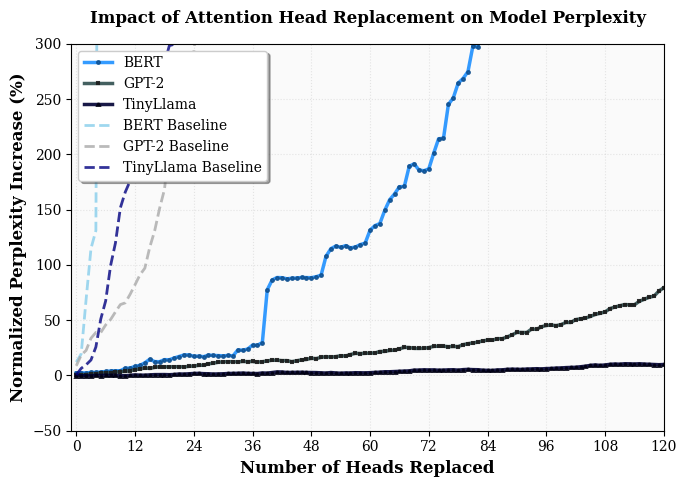

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set publication-quality parameters
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Data points - X-axis: 0 to 35 (36 total)
MAX_X = 128
x = np.arange(MAX_X)

total_heads_bert = 144
total_heads_gpt2 = 144
total_heads_tinyllama = 704

bert_file = "../results/replacement_run/bert_smart.csv"
gpt2_file = "../results/replacement_run/gpt2_smart.csv"
tinyllama_file = "../results/replacement_run/tinyllama_smart.csv"
bert_baseline_file = "../results/replacement_run/bert_baseline.csv"
gpt2_baseline_file = "../results/replacement_run/gpt2_baseline.csv"
tinyllama_baseline_file = "../results/replacement_run/tinyllama_baseline.csv"

bert = np.pad(np.array(pd.read_csv(bert_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(bert_file)["increase"])[:MAX_X])), constant_values=1050)
gpt2 = np.pad(np.array(pd.read_csv(gpt2_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(gpt2_file)["increase"])[:MAX_X])), constant_values=1050)
tiny_llama = np.pad(np.array(pd.read_csv(tinyllama_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(tinyllama_file)["increase"])[:MAX_X])), constant_values=1050)
bert_baseline = np.pad(np.array(pd.read_csv(bert_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(bert_baseline_file)["increase"])[:MAX_X])), constant_values=1050)
gpt2_baseline = np.pad(np.array(pd.read_csv(gpt2_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(gpt2_baseline_file)["increase"])[:MAX_X])), constant_values=1050)
tinyllama_baseline = np.pad(np.array(pd.read_csv(tinyllama_baseline_file)["increase"])[:MAX_X], (0, MAX_X - len(np.array(pd.read_csv(tinyllama_baseline_file)["increase"])[:MAX_X])), constant_values=1050)

# Plotting lines
ax.plot(x, bert, color='#1E90FF', linewidth=2.5, label='BERT', marker='o',
        markersize=2, markerfacecolor='#1E90FF', markeredgewidth=1.5,
        markeredgecolor='#104E8B', alpha=0.9)

ax.plot(x, gpt2, color='#2F4F4F', linewidth=2.5, label='GPT-2', marker='s',
        markersize=2, markerfacecolor='#2F4F4F', markeredgewidth=1.5,
        markeredgecolor='#1C1C1C', alpha=0.9)

# TinyLlama (dark dark blue)
ax.plot(x, tiny_llama, color='#000033', linewidth=2.5, label='TinyLlama', marker='^',
        markersize=2, markerfacecolor='#000033', markeredgewidth=1.5,
        markeredgecolor='#000011', alpha=0.9)

# Baselines
ax.plot(x, bert_baseline, color='#87CEEB', linestyle='--', linewidth=2, label='BERT Baseline', alpha=0.8)
ax.plot(x, gpt2_baseline, color='#A9A9A9', linestyle='--', linewidth=2, label='GPT-2 Baseline', alpha=0.8)
ax.plot(x, tinyllama_baseline, color='#000080', linestyle='--', linewidth=2, label='TinyLlama Baseline', alpha=0.8)

# Labels and Title
ax.set_xlabel('Number of Heads Replaced', fontweight='bold')
ax.set_ylabel('Normalized Perplexity Increase (%)', fontweight='bold')
ax.set_title('Impact of Attention Head Replacement on Model Perplexity', fontweight='bold', pad=15)

# Limits and Grid
Y_LIM = 250
ax.set_xlim(-1, 36)
ax.set_ylim(-50, Y_LIM)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)

# Ticks
ax.set_xticks(np.arange(0, MAX_X + 1, 12))
ax.set_yticks(np.arange(-50, Y_LIM + 100, 50))

# Legend and background
ax.legend(loc='upper left', frameon=True, shadow=True, fancybox=True)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../results/plots/figure_4_3.pdf', dpi=300, bbox_inches='tight', facecolor='white')

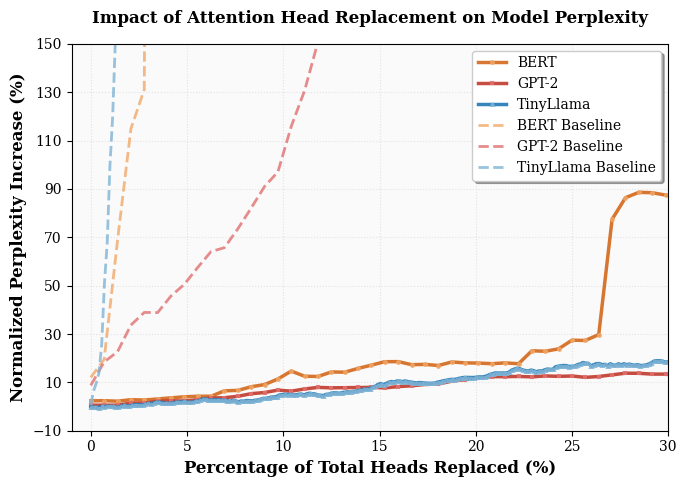

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

# Set publication-quality parameters
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

# Color mapping (consistent with Figure 4.1)
ROW_COLORS = {
    "bert":       {"box": "#f0a868", "line": "#d4681a"},
    "gpt2":       {"box": "#e07070", "line": "#c0392b"},
    "tinyllama":  {"box": "#7fb3d5", "line": "#1f77b4"},
}
# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Constants
MAX_X = 250
x_raw = np.arange(MAX_X)

total_heads_bert = 144
total_heads_gpt2 = 144
total_heads_tinyllama = 704

# Calculate percentage X-axes for each model
x_bert_pct = (x_raw / total_heads_bert) * 100
x_gpt2_pct = (x_raw / total_heads_gpt2) * 100
x_tinyllama_pct = (x_raw / total_heads_tinyllama) * 100

# File paths
bert_file = "../results/replacement_run/bert_smart.csv"
gpt2_file = "../results/replacement_run/gpt2_smart.csv"
tinyllama_file = "../results/replacement_run/tinyllama_smart.csv"
bert_baseline_file = "../results/replacement_run/bert_baseline.csv"
gpt2_baseline_file = "../results/replacement_run/gpt2_baseline.csv"
tinyllama_baseline_file = "../results/replacement_run/tinyllama_baseline.csv"

# Helper function to load data
def load_data(file):
    data = pd.read_csv(file)["increase"].values[:MAX_X]
    return np.pad(data, (0, MAX_X - len(data)), constant_values=1050)

# load in all csv shuffles in ../results/replacement_run/shuffles
all_shuffles = {} # model_key => [[]]
for f in os.listdir("../results/replacement_run/shuffles"):
    if f.startswith("bert_smart_shuffle") and f.endswith(".csv"):
        if all_shuffles.get("bert") is None: 
            all_shuffles["bert"] = []
        all_shuffles["bert"].append(load_data(os.path.join("../results/replacement_run/shuffles", f)))
    elif f.startswith("gpt2_smart_shuffle") and f.endswith(".csv"):
        if all_shuffles.get("gpt2") is None: 
            all_shuffles["gpt2"] = []
        all_shuffles["gpt2"].append(load_data(os.path.join("../results/replacement_run/shuffles", f)))
    elif f.startswith("tinyllama_smart_shuffle") and f.endswith(".csv"):
        if all_shuffles.get("tinyllama") is None: 
            all_shuffles["tinyllama"] = []
        all_shuffles["tinyllama"].append(load_data(os.path.join("../results/replacement_run/shuffles", f)))

bert = load_data(bert_file)
gpt2 = load_data(gpt2_file)
tiny_llama = load_data(tinyllama_file)
bert_baseline = load_data(bert_baseline_file)
gpt2_baseline = load_data(gpt2_baseline_file)
tinyllama_baseline = load_data(tinyllama_baseline_file)

# Plotting lines with individual percentage x-coordinates
ax.plot(x_bert_pct, bert, color=ROW_COLORS["bert"]["line"], linewidth=2.5, label='BERT', marker='o',
        markersize=2, markerfacecolor=ROW_COLORS["bert"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["bert"]["box"], alpha=0.9)

ax.plot(x_gpt2_pct, gpt2, color=ROW_COLORS["gpt2"]["line"], linewidth=2.5, label='GPT-2', marker='s',
        markersize=2, markerfacecolor=ROW_COLORS["gpt2"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["gpt2"]["box"], alpha=0.9)

ax.plot(x_tinyllama_pct, tiny_llama, color=ROW_COLORS["tinyllama"]["line"], linewidth=2.5, label='TinyLlama', marker='^',
        markersize=2, markerfacecolor=ROW_COLORS["tinyllama"]["line"], markeredgewidth=1.5,
        markeredgecolor=ROW_COLORS["tinyllama"]["box"], alpha=0.9)

# Baselines (lighter/dashed version using box color)
ax.plot(x_bert_pct, bert_baseline, color=ROW_COLORS["bert"]["box"], linestyle='--', linewidth=2, label='BERT Baseline', alpha=0.8)
ax.plot(x_gpt2_pct, gpt2_baseline, color=ROW_COLORS["gpt2"]["box"], linestyle='--', linewidth=2, label='GPT-2 Baseline', alpha=0.8)
ax.plot(x_tinyllama_pct, tinyllama_baseline, color=ROW_COLORS["tinyllama"]["box"], linestyle='--', linewidth=2, label='TinyLlama Baseline', alpha=0.8)

# Labels and Title
ax.set_xlabel('Percentage of Total Heads Replaced (%)', fontweight='bold')
ax.set_ylabel('Normalized Perplexity Increase (%)', fontweight='bold')
ax.set_title('Impact of Attention Head Replacement on Model Perplexity', fontweight='bold', pad=15)

# Limits and Grid
ax.set_xlim(-1, 30) 
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)

# Ticks (every 5%)
ax.set_xticks(np.arange(0, 31, 5))
ax.set_yticks(np.arange(-10, 151, 20))

# Legend and background
ax.legend(loc='upper right', frameon=True, shadow=True, fancybox=True)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../results/plots/figure_4_3.pdf', dpi=300, bbox_inches='tight', facecolor='white')

## Final Table: Downstream Task Accuracy Under Head Replacement

Reports benchmark performance across replacement settings to quantify downstream behavior changes after hypothesis-based head substitution.

In [28]:
# ============================================================
#  Run head replacement experiments
#  Assumes local data directory structure:
#    data/iou_scores_{model}.csv
#    data/generic_sentences.json
#    data/interpolation_k_{model}.csv
# ============================================================

np.random.seed(42)

def constrained_shuffle_df(df, sigma=2.0):
    """
    Shuffles the rows of a DataFrame based on their original 
    index position plus some Gaussian noise.
    """
    temp_df = df.copy().reset_index(drop=True)
    noise = np.random.normal(0, sigma, size=len(temp_df))
    temp_df['shuffle_pos'] = temp_df.index + noise
    shuffled_df = temp_df.sort_values('shuffle_pos').drop(columns=['shuffle_pos'])
    return shuffled_df.reset_index(drop=True)

n_shuffles = 10
os.makedirs("../results/replacement_run/shuffles", exist_ok=True)

for model_key in MODEL_CONFIGS.keys():
    if model_key == "bert": continue
    best_fits_csv = f"{RESULTS_DIR}/best_fits_{model_key}.csv"
    
    if not os.path.exists(best_fits_csv):
        print(f"  [WARN] Missing: {best_fits_csv} — skipping shuffle for {model_key}")
        continue

    original_best_fits = pd.read_csv(best_fits_csv)
    # sort original best fits by best (highest) iou score to bias towards good programs
    original_best_fits = original_best_fits.sort_values(by="iou_score", ascending=False).reset_index(drop=True)
    
    for idx in range(n_shuffles):
        print(f"\n── Running replacement for {model_key} with shuffle {idx+1} ──")
        shuffled_best_fits_df = constrained_shuffle_df(original_best_fits, sigma=2.0)

        save_path = f"../results/replacement_run/shuffles/{model_key}_smart_shuffle_{idx+1}.csv"

        if model_key == "bert":
            run_replacement_experiment_bert(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)
        elif model_key == "gpt2":
            run_replacement_experiment_gpt2(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)
        elif model_key == "tinyllama":
            run_replacement_experiment_llama(generic_sentences, shuffled_best_fits_df, all_programs, strategy="smart", save_file=save_path)


── Running replacement for gpt2 with shuffle 1 ──
Calculating baseline perplexities...
Baseline complete. Mean PPL: 43.41
Running with strategy='smart', skip_spikes=True
k=01 | Head: (7, 2) | Program: initial_element_reinforcement | Mean PPL Inc: 0.0000%
k=02 | Head: (5, 1) | Program: cls_attention | Mean PPL Inc: 0.5649%
k=03 | Head: (6, 9) | Program: initial_element_reinforcement | Mean PPL Inc: 0.5649%
k=04 | Head: (9, 9) | Program: sentence_beginning_salience | Mean PPL Inc: 0.5127%
k=05 | Head: (7, 10) | Program: sentence_beginning_salience | Mean PPL Inc: 1.2943%
k=06 | Head: (4, 11) | Program: previous_attention | Mean PPL Inc: 2.1236%
k=07 | Head: (10, 10) | Program: sentence_beginning_salience | Mean PPL Inc: 2.6371%
k=08 | Head: (10, 8) | Program: sentence_beginning_salience | Mean PPL Inc: 2.5862%
k=09 | Head: (9, 11) | Program: sentence_beginning_salience | Mean PPL Inc: 2.6843%
k=10 | Head: (9, 6) | Program: sentence_beginning_salience | Mean PPL Inc: 2.8924%
k=11 | Head:

In [27]:
# print best fits csv for gpt2

import pandas as pd

best_fits_gpt2 = pd.read_csv("../results/best_fits_gpt2.csv")
best_fits_gpt2 = best_fits_gpt2.sort_values(by="iou_score", ascending=False).reset_index(drop=True)
for idx, row in best_fits_gpt2.iterrows():
    print(f"L{int(row['layer'])}H{int(row['head'])} | Program: {all_programs[int(row['program_idx'])].__name__} | IOU: {row['iou_score']:.4f}")





L5H1 | Program: cls_attention | IOU: 0.9880
L7H2 | Program: initial_element_reinforcement | IOU: 0.9760
L6H9 | Program: initial_element_reinforcement | IOU: 0.9640
L4H11 | Program: previous_attention | IOU: 0.9560
L9H9 | Program: sentence_beginning_salience | IOU: 0.9530
L7H10 | Program: sentence_beginning_salience | IOU: 0.9480
L9H6 | Program: sentence_beginning_salience | IOU: 0.9320
L10H8 | Program: sentence_beginning_salience | IOU: 0.9200
L10H10 | Program: sentence_beginning_salience | IOU: 0.9190
L10H1 | Program: sentence_beginning_salience | IOU: 0.9180
L9H11 | Program: sentence_beginning_salience | IOU: 0.9120
L11H6 | Program: sentence_beginning_salience | IOU: 0.9090
L3H0 | Program: sentence_beginning_salience | IOU: 0.8900
L8H1 | Program: sentence_beginning_salience | IOU: 0.8870
L10H6 | Program: sentence_beginning_salience | IOU: 0.8760
L7H11 | Program: sentence_beginning_salience | IOU: 0.8670
L9H4 | Program: sentence_beginning_salience | IOU: 0.8660
L9H1 | Program: sentenc

In [33]:
# ============================================================
# Smart-Shuffle Top-3 Backtracking Experiment  (GPT-2 only)
#
# Steps 1-42 are hardcoded from the known-good run that goes
# negative. The shuffled backtracking search picks up from k=43,
# seeded with the real accepted_heads_mapping so hooks are correct.
#
# For each shuffle (steps 43+):
#   - constrained_shuffle the REMAINING heads (those not in seed)
#   - For each head try Rank-1 program (highest mean IOU).
#     If marginal PPL > 10% → try Rank-2 → Rank-3 → skip.
#   - Stop shuffle if cumulative increase > 1000%.
#
# Saves each shuffle to:
#   ../results/replacement_run/shuffles/gpt2_top3_shuffle_{idx}.csv
#
# Depends on (already defined in this notebook):
#   prepare_sentence, constrained_shuffle_df, all_programs, DATA_DIR
# ============================================================

import ast
import io
import pathlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# ── Config ────────────────────────────────────────────────────────────────────
N_SHUFFLES      = 32     # shuffles to run overnight
SPIKE_THRESHOLD = 8.0   # marginal % spike cutoff
CUMUL_LIMIT     = 66.0 # cumulative % that stops a shuffle early
TOP_K           = 3      # ranked fallbacks per head
SIGMA           = 30    # constrained-shuffle noise std-dev
NUM_SENTENCES   = 5
MODEL_KEY       = "gpt2"
# ──────────────────────────────────────────────────────────────────────────────

np.random.seed(42)
pathlib.Path("../results/replacement_run/shuffles").mkdir(parents=True, exist_ok=True)

# ── 1. Hardcoded seed — the 42 known-good replacements ───────────────────────
SEED_CSV = """\
k,head,program,strategy,increase,kl_div
1,"(10, 2)",initial_token_attention,smart,0.008307712197430366,0.001065253290653345
2,"(10, 1)",initial_token_attention,smart,0.008615101288974697,0.002011389515728297
3,"(6, 9)",cls_attention,smart,-0.6633480896656324,0.0035132152349979153
4,"(5, 1)",cls_attention,smart,-0.6251862761961215,0.006047547392081469
5,"(7, 2)",cls_attention,smart,-0.46079214514841105,0.007481090293440502
6,"(4, 11)",previous_attention,smart,-0.13227185889340462,0.008721561353304423
7,"(7, 1)",initial_token_attention,smart,0.17710685905574153,0.010167443108512088
8,"(11, 9)",initial_token_attention,smart,-0.21351424777165198,0.012792042766814121
9,"(10, 0)",initial_token_attention,smart,-0.20580384016925668,0.014605110042029992
10,"(11, 2)",initial_token_attention,smart,1.0038506419448705,0.017880274574272336
11,"(7, 7)",initial_token_attention,smart,0.9243134907948786,0.01833117724279873
12,"(5, 5)",initial_token_attention,smart,0.6361639857461907,0.020740094240172768
13,"(6, 6)",initial_token_attention,smart,0.4549912320044895,0.022376552417408675
14,"(10, 8)",initial_token_attention,smart,0.10113471498162603,0.024186684540472923
15,"(3, 0)",initial_token_attention,smart,-0.07333341108278439,0.024121518884785472
16,"(0, 1)",repeated_attention,smart,-0.08229663632499523,0.02414339571725577
17,"(9, 6)",initial_token_attention,smart,0.08397755045552856,0.02528198662563227
18,"(9, 9)",sentence_start_dominance,smart,0.20214879514749776,0.028346376998815686
19,"(9, 5)",sentence_initial_dominance,smart,-1.720343203993684,0.028143282887758688
20,"(8, 1)",initial_token_attention,smart,-1.9935828405133866,0.03228664654074237
21,"(10, 10)",initial_token_attention,smart,-1.8115494947969548,0.033806850896216926
22,"(9, 11)",initial_token_attention,smart,-1.4920480247818013,0.03443914557225071
23,"(3, 4)",initial_token_attention,smart,-1.6696160646077265,0.03623579588253051
24,"(11, 7)",initial_token_attention,smart,-0.7344831094723496,0.039611174650490286
25,"(11, 5)",initial_token_attention,smart,-0.2976022499177347,0.04332037792075425
26,"(9, 4)",initial_token_attention,smart,-0.3462717356001825,0.043809333558892834
27,"(7, 10)",initial_token_attention,smart,-0.1648400476295224,0.04461271269246936
28,"(6, 10)",initial_token_attention,smart,0.02574922911360261,0.04931675942847505
29,"(9, 8)",sentence_initial_dominance,smart,-1.440972483437424,0.0490389868686907
30,"(10, 6)",initial_token_attention,smart,-1.36646972737408,0.0513438879372552
31,"(11, 1)",sentence_initial_dominance,smart,-3.0456133521445476,0.051345947170630096
32,"(7, 11)",initial_token_attention,smart,-2.9486139101015043,0.054554718919098376
33,"(6, 2)",sentence_initial_dominance,smart,-4.1299547629687,0.05475393987959251
34,"(7, 6)",sentence_initial_dominance,smart,-5.068048806331123,0.054423859217204155
35,"(8, 3)",initial_token_attention,smart,-4.902484822870978,0.05675411381525919
36,"(5, 9)",sentence_initial_dominance,smart,-5.571243742067339,0.056279577629175036
37,"(10, 3)",sentence_initial_dominance,smart,-7.450234561946978,0.05592323972377926
38,"(5, 0)",initial_token_attention,smart,-7.127710350251196,0.06024578050011769
39,"(8, 11)",sentence_initial_dominance,smart,-8.657863908075072,0.060319892903789876
40,"(9, 1)",initial_token_attention,smart,-8.464149821736362,0.06372750320471823
41,"(8, 0)",sentence_initial_dominance,smart,-10.026851892198312,0.06297878146870062
42,"(4, 10)",initial_token_attention,smart,-9.929107592011958,0.06535566914826632\
"""

seed_df = pd.read_csv(io.StringIO(SEED_CSV))

# Build the seed accepted_heads_mapping: list of (head_tuple, prog_name)
# This is what the hook lookup is built from — must match original format exactly.
SEED_MAPPING = [
    (tuple(ast.literal_eval(row["head"])), row["program"])
    for _, row in seed_df.iterrows()
]
SEED_HEADS = set(h for h, _ in SEED_MAPPING)
SEED_PREV_CUMULATIVE = float(seed_df.iloc[-1]["increase"])  # -9.929...

print(f"[INFO] Seed loaded: {len(SEED_MAPPING)} hardcoded replacements.")
print(f"[INFO] Seed cumulative PPL increase: {SEED_PREV_CUMULATIVE:.4f}%")

# ── 2. Build top-3 program mapping from IOU scores ───────────────────────────
iou_csv  = f"{DATA_DIR}/iou_scores_{MODEL_KEY}.csv"
iou_df   = pd.read_csv(iou_csv)
mean_iou = (
    iou_df.groupby(["layer", "head", "program_idx"])["iou_score"]
    .mean()
    .reset_index()
)

head_program_map = {}  # (layer, head) -> [(rank, prog_name), ...]
rank1_rows       = []  # for shuffling — only non-seed heads

for (layer, head), grp in mean_iou.groupby(["layer", "head"]):
    top    = grp.nlargest(TOP_K, "iou_score").reset_index(drop=True)
    ranked = []
    for rank_idx, (_, row) in enumerate(top.iterrows(), start=1):
        p_idx     = int(row["program_idx"])
        prog_name = all_programs[p_idx].__name__
        ranked.append((rank_idx, prog_name))
        if rank_idx == 1 and (int(layer), int(head)) not in SEED_HEADS:
            rank1_rows.append({"layer": layer, "head": head, "iou_score": row["iou_score"]})
    head_program_map[(int(layer), int(head))] = ranked

# Remaining heads (not in seed), ordered by rank-1 IOU desc — this is what we shuffle
remaining_rank1_df = pd.DataFrame(rank1_rows).sort_values("iou_score", ascending=False).reset_index(drop=True)

print(f"[INFO] {len(head_program_map)} total unique heads, {len(remaining_rank1_df)} remaining after seed.")

# ── 3. Baseline (computed once, reused across all shuffles) ───────────────────
tokenizer  = GPT2Tokenizer.from_pretrained("gpt2")
eval_sents = pd.read_json("../data/generic_sentences.json")[0].tolist()[:NUM_SENTENCES]

print("Calculating baseline perplexities...")
_base  = GPT2LMHeadModel.from_pretrained("gpt2").to("cuda" if torch.cuda.is_available() else "cpu")
_base.eval()
device          = next(_base.parameters()).device
baseline_ppls   = []
baseline_logits = []

for sent in eval_sents:
    active = prepare_sentence(sent, mode="last_word")
    toks   = tokenizer(active, return_tensors="pt").to(device)
    with torch.no_grad():
        out = _base(**toks, labels=toks["input_ids"])
        baseline_ppls.append(torch.exp(out.loss).item())
        baseline_logits.append(out.logits[:, -1, :])

del _base
torch.cuda.empty_cache()
print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}\n")

# ── 4. Hook factory — copied verbatim from run_replacement_experiment_gpt2 ────
def make_smart_hook(lookup, programs_list):
    def compound_hook(module, input, output):
        context_layer = output[0]
        batch, seq_len, hidden_dim = context_layer.shape
        num_heads, head_dim = 12, hidden_dim // 12
        modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
        current_sent = getattr(module, '_current_sentence', None)
        if current_sent is None:
            return output
        for head_idx in range(num_heads):
            key = (module.layer_id, head_idx)
            if key in lookup:
                prog_name = lookup[key]
                prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                if prog:
                    try:
                        _, hypo_mat = prog(current_sent, tokenizer)
                        if hypo_mat is not None:
                            hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                            modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                    except Exception:
                        pass
        return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
    return compound_hook

# ── 5. Trial evaluator — inner loop from run_replacement_experiment_gpt2 ──────
def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
    """
    Loads a fresh GPT-2, registers hooks for all accepted heads + candidate,
    evaluates, cleans up. Returns (mean_pct_increase, mean_kl_div).

    accepted_heads_mapping: list of (head_tuple, prog_name)
    """
    trial_mapping   = accepted_heads_mapping + [(candidate_head, candidate_prog)]
    trial_lookup    = {tuple(map(int, h)): p for h, p in trial_mapping}
    relevant_layers = set(h[0] for h in trial_lookup)

    model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_k.eval()

    hook_fn      = make_smart_hook(trial_lookup, all_programs)
    hook_handles = []
    for l_idx in range(12):
        target          = model_k.transformer.h[l_idx].attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            hook_handles.append(target.register_forward_hook(hook_fn))

    replaced_ppls, kl_divergences = [], []
    for i, sent in enumerate(eval_sents):
        active_sent = prepare_sentence(sent, mode="last_word")
        for l_idx in relevant_layers:
            model_k.transformer.h[l_idx].attn._current_sentence = active_sent
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out_rep = model_k(**toks, labels=toks["input_ids"])
            replaced_ppls.append(torch.exp(out_rep.loss).item())
            log_probs_new  = F.log_softmax(out_rep.logits[:, -1, :], dim=-1)
            probs_baseline = F.softmax(baseline_logits[i], dim=-1)
            kl_divergences.append(F.kl_div(log_probs_new, probs_baseline, reduction='batchmean').item())

    for handle in hook_handles:
        handle.remove()
    del model_k
    torch.cuda.empty_cache()

    mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
    mean_kl  = float(np.mean(kl_divergences))
    return mean_pct, mean_kl

# ── 6. Outer shuffle loop ─────────────────────────────────────────────────────
for shuffle_idx in range(1, N_SHUFFLES + 1):
    print(f"── Shuffle {shuffle_idx}/{N_SHUFFLES} ──────────────────────────────")

    # Seed results are identical across every shuffle — copy them in directly
    shuffle_results = [
        {
            "k":             int(row["k"]),
            "head":          row["head"],
            "program":       row["program"],
            "accepted_rank": 1,          # seed rows are always rank-1 by definition
            "strategy":      "smart",
            "increase":      float(row["increase"]),
            "kl_div":        float(row["kl_div"]),
            "shuffle_idx":   shuffle_idx,
        }
        for _, row in seed_df.iterrows()
    ]
    for row in shuffle_results:
        print(f"  [SEED] k={row['k']:03d} | Head {row['head']} | '{row['program']}' | cumul={row['increase']:.4f}%")

    # Seed the accepted mapping so hooks include all 42 replacements
    accepted_heads_mapping = list(SEED_MAPPING)   # copy — mutated per shuffle
    k               = len(SEED_MAPPING)           # 42
    prev_cumulative = SEED_PREV_CUMULATIVE        # -9.929...

    # Shuffle only the remaining (non-seed) heads
    shuffled_remaining = constrained_shuffle_df(remaining_rank1_df, sigma=SIGMA)
    head_order = [(int(r["layer"]), int(r["head"])) for _, r in shuffled_remaining.iterrows()]

    for head_tuple in head_order:
        candidates = head_program_map.get(head_tuple, [])
        if not candidates:
            print(f"  [WARN] No candidates for head {head_tuple}. Skipping.")
            continue

        accepted_rank = None
        accepted_prog = None
        mean_pct      = None
        mean_kl       = None

        # ── Backtracking: Rank 1 → 2 → 3 ──────────────────────────────────
        for rank, prog_name in candidates:
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal          = mean_pct - prev_cumulative

            if marginal > SPIKE_THRESHOLD:
                n_remaining = len(candidates) - rank
                print(
                    f"  [SPIKE] Head {head_tuple} Rank-{rank} '{prog_name}' "
                    f"marginal={marginal:.2f}%. "
                    + (f"Trying Rank-{rank+1}..." if n_remaining > 0 else "All ranks exhausted.")
                )
                torch.cuda.empty_cache()
                continue

            accepted_rank = rank
            accepted_prog = prog_name
            break

        if accepted_rank is None:
            print(f"  [SKIP] Head {head_tuple}: all {len(candidates)} programs spiked.")
            continue

        if mean_pct > CUMUL_LIMIT:
            print(f"  [STOP] Cumulative {mean_pct:.2f}% > {CUMUL_LIMIT}%. Ending shuffle {shuffle_idx} early.")
            break

        k += 1
        accepted_heads_mapping.append((head_tuple, accepted_prog))
        prev_cumulative = mean_pct

        shuffle_results.append({
            "k":             k,
            "head":          str(head_tuple),
            "program":       accepted_prog,
            "accepted_rank": accepted_rank,
            "strategy":      "smart",
            "increase":      round(mean_pct, 6),
            "kl_div":        round(mean_kl, 6),
            "shuffle_idx":   shuffle_idx,
        })
        print(f"  k={k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{accepted_prog}' | cumul={mean_pct:.4f}%")

    # Save this shuffle
    save_path = f"../results/replacement_run/shuffles/{MODEL_KEY}_top3_shuffle_{shuffle_idx}.csv"
    pd.DataFrame(shuffle_results).to_csv(save_path, index=False)
    print(f"  ✓ Saved {len(shuffle_results)} rows → {save_path}\n")

print(f"[DONE] All {N_SHUFFLES} shuffles complete.")

[INFO] Seed loaded: 42 hardcoded replacements.
[INFO] Seed cumulative PPL increase: -9.9291%
[INFO] 144 total unique heads, 102 remaining after seed.
Calculating baseline perplexities...
Baseline complete. Mean PPL: 43.41

── Shuffle 1/32 ──────────────────────────────
  [SEED] k=001 | Head (10, 2) | 'initial_token_attention' | cumul=0.0083%
  [SEED] k=002 | Head (10, 1) | 'initial_token_attention' | cumul=0.0086%
  [SEED] k=003 | Head (6, 9) | 'cls_attention' | cumul=-0.6633%
  [SEED] k=004 | Head (5, 1) | 'cls_attention' | cumul=-0.6252%
  [SEED] k=005 | Head (7, 2) | 'cls_attention' | cumul=-0.4608%
  [SEED] k=006 | Head (4, 11) | 'previous_attention' | cumul=-0.1323%
  [SEED] k=007 | Head (7, 1) | 'initial_token_attention' | cumul=0.1771%
  [SEED] k=008 | Head (11, 9) | 'initial_token_attention' | cumul=-0.2135%
  [SEED] k=009 | Head (10, 0) | 'initial_token_attention' | cumul=-0.2058%
  [SEED] k=010 | Head (11, 2) | 'initial_token_attention' | cumul=1.0039%
  [SEED] k=011 | Head (

In [35]:
# ============================================================
# Smart-Shuffle Top-3 Backtracking Experiment  (GPT-2 only)
#
# Steps 1-42 are hardcoded from the known-good run that goes
# negative. The shuffled backtracking search picks up from k=43,
# seeded with the real accepted_heads_mapping so hooks are correct.
#
# For each shuffle (steps 43+):
#   - constrained_shuffle the REMAINING heads (those not in seed)
#   - For each head try Rank-1 program (highest mean IOU).
#     If marginal PPL > 10% → try Rank-2 → Rank-3 → skip.
#   - Stop shuffle if cumulative increase > 1000%.
#
# Saves each shuffle to:
#   ../results/replacement_run/shuffles/gpt2_top3_shuffle_{idx}.csv
#
# Depends on (already defined in this notebook):
#   prepare_sentence, constrained_shuffle_df, all_programs, DATA_DIR
# ============================================================

import ast
import io
import pathlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# ── Config ────────────────────────────────────────────────────────────────────
N_SHUFFLES      = 32     # shuffles to run overnight
SPIKE_THRESHOLD = 5.0   # marginal % spike cutoff
CUMUL_LIMIT     = 25.0 # cumulative % that stops a shuffle early
TOP_K           = 5      # ranked fallbacks per head
SIGMA           = 20    # constrained-shuffle noise std-dev
NUM_SENTENCES   = 7
MODEL_KEY       = "gpt2"
# ──────────────────────────────────────────────────────────────────────────────

np.random.seed(42)
pathlib.Path("../results/replacement_run/shuffles").mkdir(parents=True, exist_ok=True)

# ── 1. Hardcoded seed — the 42 known-good replacements ───────────────────────
SEED_CSV = """\
k,head,program,strategy,increase,kl_div
1,"(10, 2)",initial_token_attention,smart,0.008307712197430366,0.001065253290653345
2,"(10, 1)",initial_token_attention,smart,0.008615101288974697,0.002011389515728297
3,"(6, 9)",cls_attention,smart,-0.6633480896656324,0.0035132152349979153
4,"(5, 1)",cls_attention,smart,-0.6251862761961215,0.006047547392081469
5,"(7, 2)",cls_attention,smart,-0.46079214514841105,0.007481090293440502
6,"(4, 11)",previous_attention,smart,-0.13227185889340462,0.008721561353304423
7,"(7, 1)",initial_token_attention,smart,0.17710685905574153,0.010167443108512088
8,"(11, 9)",initial_token_attention,smart,-0.21351424777165198,0.012792042766814121
9,"(10, 0)",initial_token_attention,smart,-0.20580384016925668,0.014605110042029992
10,"(11, 2)",initial_token_attention,smart,1.0038506419448705,0.017880274574272336
11,"(7, 7)",initial_token_attention,smart,0.9243134907948786,0.01833117724279873
12,"(5, 5)",initial_token_attention,smart,0.6361639857461907,0.020740094240172768
13,"(6, 6)",initial_token_attention,smart,0.4549912320044895,0.022376552417408675
14,"(10, 8)",initial_token_attention,smart,0.10113471498162603,0.024186684540472923
15,"(3, 0)",initial_token_attention,smart,-0.07333341108278439,0.024121518884785472
16,"(0, 1)",repeated_attention,smart,-0.08229663632499523,0.02414339571725577
17,"(9, 6)",initial_token_attention,smart,0.08397755045552856,0.02528198662563227
18,"(9, 9)",sentence_start_dominance,smart,0.20214879514749776,0.028346376998815686
19,"(9, 5)",sentence_initial_dominance,smart,-1.720343203993684,0.028143282887758688
20,"(8, 1)",initial_token_attention,smart,-1.9935828405133866,0.03228664654074237
21,"(10, 10)",initial_token_attention,smart,-1.8115494947969548,0.033806850896216926
22,"(9, 11)",initial_token_attention,smart,-1.4920480247818013,0.03443914557225071
23,"(3, 4)",initial_token_attention,smart,-1.6696160646077265,0.03623579588253051
24,"(11, 7)",initial_token_attention,smart,-0.7344831094723496,0.039611174650490286
25,"(11, 5)",initial_token_attention,smart,-0.2976022499177347,0.04332037792075425
26,"(9, 4)",initial_token_attention,smart,-0.3462717356001825,0.043809333558892834
27,"(7, 10)",initial_token_attention,smart,-0.1648400476295224,0.04461271269246936
28,"(6, 10)",initial_token_attention,smart,0.02574922911360261,0.04931675942847505
29,"(9, 8)",sentence_initial_dominance,smart,-1.440972483437424,0.0490389868686907
30,"(10, 6)",initial_token_attention,smart,-1.36646972737408,0.0513438879372552
31,"(11, 1)",sentence_initial_dominance,smart,-3.0456133521445476,0.051345947170630096
32,"(7, 11)",initial_token_attention,smart,-2.9486139101015043,0.054554718919098376
33,"(6, 2)",sentence_initial_dominance,smart,-4.1299547629687,0.05475393987959251
34,"(7, 6)",sentence_initial_dominance,smart,-5.068048806331123,0.054423859217204155
35,"(8, 3)",initial_token_attention,smart,-4.902484822870978,0.05675411381525919
36,"(5, 9)",sentence_initial_dominance,smart,-5.571243742067339,0.056279577629175036
37,"(10, 3)",sentence_initial_dominance,smart,-7.450234561946978,0.05592323972377926
38,"(5, 0)",initial_token_attention,smart,-7.127710350251196,0.06024578050011769
39,"(8, 11)",sentence_initial_dominance,smart,-8.657863908075072,0.060319892903789876
40,"(9, 1)",initial_token_attention,smart,-8.464149821736362,0.06372750320471823
41,"(8, 0)",sentence_initial_dominance,smart,-10.026851892198312,0.06297878146870062
42,"(4, 10)",initial_token_attention,smart,-9.929107592011958,0.06535566914826632\
"""

seed_df = pd.read_csv(io.StringIO(SEED_CSV))

# Build the seed accepted_heads_mapping: list of (head_tuple, prog_name)
# This is what the hook lookup is built from — must match original format exactly.
SEED_MAPPING = [
    (tuple(ast.literal_eval(row["head"])), row["program"])
    for _, row in seed_df.iterrows()
]
SEED_HEADS = set(h for h, _ in SEED_MAPPING)
SEED_PREV_CUMULATIVE = float(seed_df.iloc[-1]["increase"])  # -9.929...

print(f"[INFO] Seed loaded: {len(SEED_MAPPING)} hardcoded replacements.")
print(f"[INFO] Seed cumulative PPL increase: {SEED_PREV_CUMULATIVE:.4f}%")

# ── 2. Build top-3 program mapping from IOU scores ───────────────────────────
iou_csv  = f"{DATA_DIR}/iou_scores_{MODEL_KEY}.csv"
iou_df   = pd.read_csv(iou_csv)
mean_iou = (
    iou_df.groupby(["layer", "head", "program_idx"])["iou_score"]
    .mean()
    .reset_index()
)

head_program_map = {}  # (layer, head) -> [(rank, prog_name), ...]
rank1_rows       = []  # for shuffling — only non-seed heads

for (layer, head), grp in mean_iou.groupby(["layer", "head"]):
    top    = grp.nlargest(TOP_K, "iou_score").reset_index(drop=True)
    ranked = []
    for rank_idx, (_, row) in enumerate(top.iterrows(), start=1):
        p_idx     = int(row["program_idx"])
        prog_name = all_programs[p_idx].__name__
        ranked.append((rank_idx, prog_name))
        if rank_idx == 1 and (int(layer), int(head)) not in SEED_HEADS:
            rank1_rows.append({"layer": layer, "head": head, "iou_score": row["iou_score"]})
    head_program_map[(int(layer), int(head))] = ranked

# Remaining heads (not in seed), ordered by rank-1 IOU desc — this is what we shuffle
remaining_rank1_df = pd.DataFrame(rank1_rows).sort_values("iou_score", ascending=False).reset_index(drop=True)

print(f"[INFO] {len(head_program_map)} total unique heads, {len(remaining_rank1_df)} remaining after seed.")

# ── 3. Baseline (computed once, reused across all shuffles) ───────────────────
tokenizer  = GPT2Tokenizer.from_pretrained("gpt2")
eval_sents = pd.read_json("../data/generic_sentences.json")[0].tolist()[:NUM_SENTENCES]

print("Calculating baseline perplexities...")
_base  = GPT2LMHeadModel.from_pretrained("gpt2").to("cuda" if torch.cuda.is_available() else "cpu")
_base.eval()
device          = next(_base.parameters()).device
baseline_ppls   = []
baseline_logits = []

for sent in eval_sents:
    active = prepare_sentence(sent, mode="last_word")
    toks   = tokenizer(active, return_tensors="pt").to(device)
    with torch.no_grad():
        out = _base(**toks, labels=toks["input_ids"])
        baseline_ppls.append(torch.exp(out.loss).item())
        baseline_logits.append(out.logits[:, -1, :])

del _base
torch.cuda.empty_cache()
print(f"Baseline complete. Mean PPL: {np.mean(baseline_ppls):.2f}\n")

# ── 4. Hook factory — copied verbatim from run_replacement_experiment_gpt2 ────
def make_smart_hook(lookup, programs_list):
    def compound_hook(module, input, output):
        context_layer = output[0]
        batch, seq_len, hidden_dim = context_layer.shape
        num_heads, head_dim = 12, hidden_dim // 12
        modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
        current_sent = getattr(module, '_current_sentence', None)
        if current_sent is None:
            return output
        for head_idx in range(num_heads):
            key = (module.layer_id, head_idx)
            if key in lookup:
                prog_name = lookup[key]
                prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                if prog:
                    try:
                        _, hypo_mat = prog(current_sent, tokenizer)
                        if hypo_mat is not None:
                            hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                            modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                    except Exception:
                        pass
        return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
    return compound_hook

# ── 5. Trial evaluator — inner loop from run_replacement_experiment_gpt2 ──────
def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
    """
    Loads a fresh GPT-2, registers hooks for all accepted heads + candidate,
    evaluates, cleans up. Returns (mean_pct_increase, mean_kl_div).

    accepted_heads_mapping: list of (head_tuple, prog_name)
    """
    trial_mapping   = accepted_heads_mapping + [(candidate_head, candidate_prog)]
    trial_lookup    = {tuple(map(int, h)): p for h, p in trial_mapping}
    relevant_layers = set(h[0] for h in trial_lookup)

    model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_k.eval()

    hook_fn      = make_smart_hook(trial_lookup, all_programs)
    hook_handles = []
    for l_idx in range(12):
        target          = model_k.transformer.h[l_idx].attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            hook_handles.append(target.register_forward_hook(hook_fn))

    replaced_ppls, kl_divergences = [], []
    for i, sent in enumerate(eval_sents):
        active_sent = prepare_sentence(sent, mode="last_word")
        for l_idx in relevant_layers:
            model_k.transformer.h[l_idx].attn._current_sentence = active_sent
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out_rep = model_k(**toks, labels=toks["input_ids"])
            replaced_ppls.append(torch.exp(out_rep.loss).item())
            log_probs_new  = F.log_softmax(out_rep.logits[:, -1, :], dim=-1)
            probs_baseline = F.softmax(baseline_logits[i], dim=-1)
            kl_divergences.append(F.kl_div(log_probs_new, probs_baseline, reduction='batchmean').item())

    for handle in hook_handles:
        handle.remove()
    del model_k
    torch.cuda.empty_cache()

    mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
    mean_kl  = float(np.mean(kl_divergences))
    return mean_pct, mean_kl

# ── 6. Outer shuffle loop ─────────────────────────────────────────────────────
for shuffle_idx in range(1, N_SHUFFLES + 1):
    print(f"── Shuffle {shuffle_idx}/{N_SHUFFLES} ──────────────────────────────")

    # Seed results are identical across every shuffle — copy them in directly
    shuffle_results = [
        {
            "k":             int(row["k"]),
            "head":          row["head"],
            "program":       row["program"],
            "accepted_rank": 1,          # seed rows are always rank-1 by definition
            "strategy":      "smart",
            "increase":      float(row["increase"]),
            "kl_div":        float(row["kl_div"]),
            "shuffle_idx":   shuffle_idx,
        }
        for _, row in seed_df.iterrows()
    ]
    for row in shuffle_results:
        print(f"  [SEED] k={row['k']:03d} | Head {row['head']} | '{row['program']}' | cumul={row['increase']:.4f}%")

    # Seed the accepted mapping so hooks include all 42 replacements
    accepted_heads_mapping = list(SEED_MAPPING)   # copy — mutated per shuffle
    k               = len(SEED_MAPPING)           # 42
    prev_cumulative = SEED_PREV_CUMULATIVE        # -9.929...

    # Shuffle only the remaining (non-seed) heads
    shuffled_remaining = constrained_shuffle_df(remaining_rank1_df, sigma=SIGMA)
    head_order = [(int(r["layer"]), int(r["head"])) for _, r in shuffled_remaining.iterrows()]

    for head_tuple in head_order:
        candidates = head_program_map.get(head_tuple, [])
        if not candidates:
            print(f"  [WARN] No candidates for head {head_tuple}. Skipping.")
            continue

        accepted_rank = None
        accepted_prog = None
        mean_pct      = None
        mean_kl       = None

        # ── Backtracking: Rank 1 → 2 → 3 ──────────────────────────────────
        for rank, prog_name in candidates:
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal          = mean_pct - prev_cumulative

            if marginal > SPIKE_THRESHOLD:
                n_remaining = len(candidates) - rank
                print(
                    f"  [SPIKE] Head {head_tuple} Rank-{rank} '{prog_name}' "
                    f"marginal={marginal:.2f}%. "
                    + (f"Trying Rank-{rank+1}..." if n_remaining > 0 else "All ranks exhausted.")
                )
                torch.cuda.empty_cache()
                continue

            accepted_rank = rank
            accepted_prog = prog_name
            break

        if accepted_rank is None:
            print(f"  [SKIP] Head {head_tuple}: all {len(candidates)} programs spiked.")
            continue

        if mean_pct > CUMUL_LIMIT:
            print(f"  [STOP] Cumulative {mean_pct:.2f}% > {CUMUL_LIMIT}%. Ending shuffle {shuffle_idx} early.")
            break

        k += 1
        accepted_heads_mapping.append((head_tuple, accepted_prog))
        prev_cumulative = mean_pct

        shuffle_results.append({
            "k":             k,
            "head":          str(head_tuple),
            "program":       accepted_prog,
            "accepted_rank": accepted_rank,
            "strategy":      "smart",
            "increase":      round(mean_pct, 6),
            "kl_div":        round(mean_kl, 6),
            "shuffle_idx":   shuffle_idx,
        })
        print(f"  k={k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{accepted_prog}' | cumul={mean_pct:.4f}%")

    # Save this shuffle
    save_path = f"../results/replacement_run/shuffles/{MODEL_KEY}_top3_shuffle_{shuffle_idx+32}.csv"
    pd.DataFrame(shuffle_results).to_csv(save_path, index=False)
    print(f"  ✓ Saved {len(shuffle_results)} rows → {save_path}\n")

print(f"[DONE] All {N_SHUFFLES} shuffles complete.")

[INFO] Seed loaded: 42 hardcoded replacements.
[INFO] Seed cumulative PPL increase: -9.9291%
[INFO] 144 total unique heads, 102 remaining after seed.
Calculating baseline perplexities...
Baseline complete. Mean PPL: 44.11

── Shuffle 1/32 ──────────────────────────────
  [SEED] k=001 | Head (10, 2) | 'initial_token_attention' | cumul=0.0083%
  [SEED] k=002 | Head (10, 1) | 'initial_token_attention' | cumul=0.0086%
  [SEED] k=003 | Head (6, 9) | 'cls_attention' | cumul=-0.6633%
  [SEED] k=004 | Head (5, 1) | 'cls_attention' | cumul=-0.6252%
  [SEED] k=005 | Head (7, 2) | 'cls_attention' | cumul=-0.4608%
  [SEED] k=006 | Head (4, 11) | 'previous_attention' | cumul=-0.1323%
  [SEED] k=007 | Head (7, 1) | 'initial_token_attention' | cumul=0.1771%
  [SEED] k=008 | Head (11, 9) | 'initial_token_attention' | cumul=-0.2135%
  [SEED] k=009 | Head (10, 0) | 'initial_token_attention' | cumul=-0.2058%
  [SEED] k=010 | Head (11, 2) | 'initial_token_attention' | cumul=1.0039%
  [SEED] k=011 | Head (

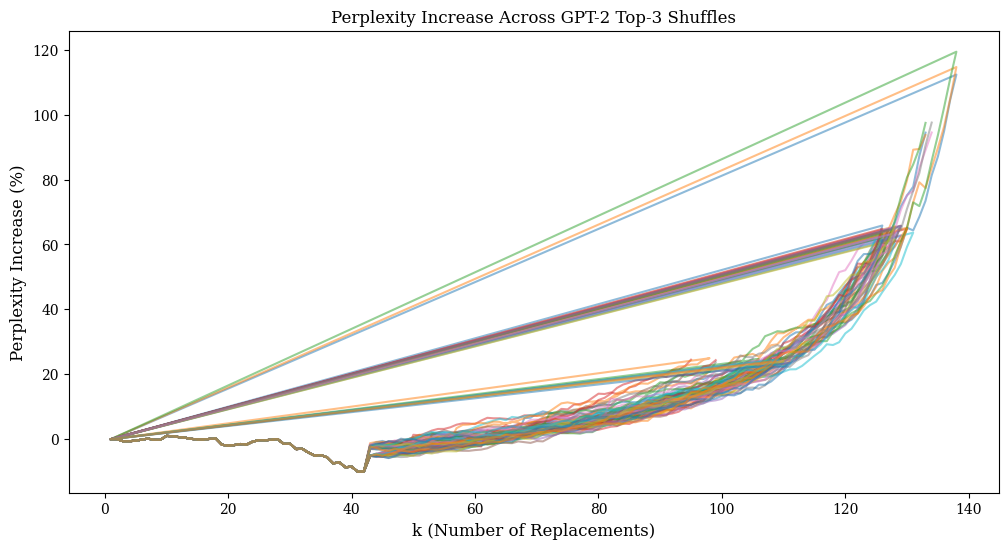

In [ ]:
# read the 72 shuffles from paper_results\results\replacement_run\shuffles\gpt2_top3_shuffle_1.csv and plot their increase on same plot, alpha 0.5, with a line for the mean increase across shuffles at each k, and a shaded area for the std deviation across shuffles at each k. Save the plot as gpt2_top3_shuffles.png

from pathlib import Path
import matplotlib.pyplot as plt

# Read all shuffle CSVs
shuffle_dir = Path("../results/replacement_run/shuffles")
shuffle_files = list(shuffle_dir.glob("gpt2_top3_shuffle_*.csv"))
all_shuffles = []
for file in shuffle_files:
    df = pd.read_csv(file)
    all_shuffles.append(df)

# Concatenate all shuffles into a single DataFrame
shuffles_df = pd.concat(all_shuffles, ignore_index=True)
# Group by 'k' to calculate mean and std deviation
grouped = shuffles_df.groupby('k')['increase'].agg(['mean', 'std']).reset_index()
# Plotting
plt.figure(figsize=(12, 6))
# Plot each shuffle with low alpha
for shuffle_idx in shuffles_df['shuffle_idx'].unique():
    subset = shuffles_df[shuffles_df['shuffle_idx'] == shuffle_idx]
    plt.plot(subset['k'], subset['increase'], alpha=0.5, label=f'Shuffle {shuffle_idx}')
# Plot mean increase with std deviation shaded area
# plt.plot(grouped['k'], grouped['mean'], color='black', label='Mean Increase', linewidth=2)
# plt.fill_between(grouped['k'], grouped['mean'] - grouped['std'], grouped['mean'] + grouped['std'], color='gray', alpha=0.3, label='Std Deviation')
plt.xlabel('k (Number of Replacements)')
plt.ylabel('Perplexity Increase (%)')
plt.title('Perplexity Increase Across GPT-2 Top-3 Shuffles')
# plt.legend()
plt.grid()

# plt.savefig("gpt2_top3_shuffles.png")
plt.show()

In [9]:
from pathlib import Path
import ast
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BertForMaskedLM, GPT2LMHeadModel, GPT2Tokenizer

import logging
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

shuffle_dir = Path("../results/replacement_run/shuffles")
best_fits_folder = Path("../results")

# file, number of heads still needed to reach 100% replacement
get_to_100percent_replacements = [
    (shuffle_dir / "gpt2_smart_shuffle_8.csv", 3),
    (shuffle_dir / "bert_smart_shuffle_5.csv", 35),
    (shuffle_dir / "tinyllama_smart_shuffle_2.csv", 454),
]

head_counts = {
    "bert": 144,
    "gpt2": 144,
    "tinyllama": 704,
}

SPIKE_THRESHOLD = 100.0
TAIL_HEADS_TO_SEARCH = 104
TAIL_CANDIDATE_LIMIT = 3
NUM_SENTENCES = 5
TINYLLAMA_MODEL_ID = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"


def _parse_model_key(csv_path: Path) -> str:
    return csv_path.name.split("_")[0].lower()


def _parse_head(raw_head):
    if isinstance(raw_head, tuple):
        return (int(raw_head[0]), int(raw_head[1]))
    if isinstance(raw_head, list):
        return (int(raw_head[0]), int(raw_head[1]))
    if isinstance(raw_head, str):
        parsed = ast.literal_eval(raw_head)
        return (int(parsed[0]), int(parsed[1]))
    raise ValueError(f"Unrecognized head format: {raw_head}")


def _load_eval_sentences():
    return pd.read_json("../data/generic_sentences.json")[0].tolist()[:NUM_SENTENCES]


def _mean_sequence_kl(logits_new, logits_base):
    return F.kl_div(
        F.log_softmax(logits_new, dim=-1),
        F.softmax(logits_base, dim=-1),
        reduction="batchmean",
    ).item()


def _build_seed_mapping(seed_df):
    return [(_parse_head(row["head"]), str(row["program"])) for _, row in seed_df.iterrows()]


def _build_head_program_candidates(model_key, top_k=TAIL_CANDIDATE_LIMIT):
    iou_csv = Path(DATA_DIR) / f"iou_scores_{model_key}.csv"
    iou_df = pd.read_csv(iou_csv)
    mean_iou = (
        iou_df.groupby(["layer", "head", "program_idx"])["iou_score"]
        .mean()
        .reset_index()
    )

    head_program_candidates = {}
    for (layer, head), grp in mean_iou.groupby(["layer", "head"]):
        top = grp.nlargest(top_k, "iou_score").reset_index(drop=True)
        head_program_candidates[(int(layer), int(head))] = [
            all_programs[int(row["program_idx"])].__name__
            for _, row in top.iterrows()
        ]
    return head_program_candidates


def _finalize_and_save(rows, seed_df, save_path):
    final_df = pd.DataFrame(rows)
    for column in seed_df.columns:
        if column not in final_df.columns:
            final_df[column] = pd.NA
    final_df = final_df.reindex(columns=list(seed_df.columns))
    final_df.to_csv(save_path, index=False)
    return final_df


def _full_perplexity(sentence, model, tokenizer, device):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    seq_len = input_ids.shape[1]
    log_probs = []
    for i in range(1, seq_len - 1):
        masked = input_ids.clone()
        masked[0, i] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = model(masked).logits
        prob = torch.log_softmax(logits[0, i], dim=-1)[input_ids[0, i]]
        log_probs.append(prob)
    return torch.exp(-torch.stack(log_probs).mean()).item()


def _choose_tail_candidate(accepted_heads_mapping, head_tuple, candidate_programs, evaluate_candidate, prev_cumulative):
    candidate_programs = list(dict.fromkeys(candidate_programs))[:TAIL_CANDIDATE_LIMIT]
    best_choice = None

    for rank, prog_name in enumerate(candidate_programs, start=1):
        mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
        marginal = mean_pct - prev_cumulative

        if best_choice is None or mean_pct < best_choice["mean_pct"]:
            best_choice = {
                "rank": rank,
                "prog_name": prog_name,
                "mean_pct": mean_pct,
                "mean_kl": mean_kl,
                "marginal": marginal,
            }

        print(f"  [TAIL-TRY] Head {head_tuple} Rank-{rank} '{prog_name}' | marginal={marginal:.2f}%")

        if marginal <= SPIKE_THRESHOLD:
            return {
                "rank": rank,
                "prog_name": prog_name,
                "mean_pct": mean_pct,
                "mean_kl": mean_kl,
                "marginal": marginal,
            }

    print(f"  [TAIL] Head {head_tuple}: no candidate cleared {SPIKE_THRESHOLD:.0f}%; using best of {len(candidate_programs)} candidates.")
    return best_choice


def _continue_gpt2(seed_df, remaining_df, save_path):
    eval_sents = _load_eval_sentences()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    head_program_candidates = _build_head_program_candidates("gpt2")

    print("[INFO] GPT2: calculating baseline perplexities...")
    base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    base_model.eval()
    baseline_ppls = []
    baseline_logits = []
    for sent in eval_sents:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out = base_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(out.loss).item())
            baseline_logits.append(out.logits[:, -1, :])
    del base_model
    torch.cuda.empty_cache()

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, "_current_sentence", None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
        trial_mapping = accepted_heads_mapping + [(candidate_head, candidate_prog)]
        trial_lookup = {tuple(map(int, h)): p for h, p in trial_mapping}
        relevant_layers = set(h[0] for h in trial_lookup)

        model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        model_k.eval()

        hook_fn = make_smart_hook(trial_lookup, all_programs)
        hook_handles = []
        for l_idx in range(12):
            target = model_k.transformer.h[l_idx].attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sents):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.transformer.h[l_idx].attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = model_k(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                kl_divergences.append(_mean_sequence_kl(out_rep.logits[:, -1, :], baseline_logits[i]))

        for handle in hook_handles:
            handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
        mean_kl = float(np.mean(kl_divergences))
        return mean_pct, mean_kl

    accepted_heads_mapping = _build_seed_mapping(seed_df)
    rows = seed_df.to_dict(orient="records")
    current_k = int(seed_df.iloc[-1]["k"])
    prev_cumulative = float(seed_df.iloc[-1]["increase"])

    total_remaining = len(remaining_df)
    for idx, (_, row) in enumerate(remaining_df.iterrows()):
        head_tuple = (int(row["layer"]), int(row["head"]))
        default_prog = all_programs[int(row["program_idx"])].__name__

        if total_remaining - idx <= TAIL_HEADS_TO_SEARCH:
            candidate_programs = head_program_candidates.get(head_tuple, [])
            if default_prog not in candidate_programs:
                candidate_programs = [default_prog] + candidate_programs
            choice = _choose_tail_candidate(
                accepted_heads_mapping,
                head_tuple,
                candidate_programs,
                evaluate_candidate,
                prev_cumulative,
            )
            prog_name = choice["prog_name"]
            mean_pct = choice["mean_pct"]
            mean_kl = choice["mean_kl"]
            marginal = choice["marginal"]
            accepted_rank = choice["rank"]
        else:
            prog_name = default_prog
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal = mean_pct - prev_cumulative
            accepted_rank = 1

        current_k += 1
        accepted_heads_mapping.append((head_tuple, prog_name))

        new_row = {
            "k": current_k,
            "head": str(head_tuple),
            "program": prog_name,
            "strategy": "smart",
            "increase": round(mean_pct, 6),
            "spike": bool(marginal > SPIKE_THRESHOLD),
        }
        if "kl_div" in seed_df.columns:
            new_row["kl_div"] = round(mean_kl, 6)
        rows.append(new_row)
        prev_cumulative = mean_pct
        print(f"  [APPEND] k={current_k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{prog_name}' | cumul={mean_pct:.4f}%")

    return _finalize_and_save(rows, seed_df, save_path)


def _continue_bert(seed_df, remaining_df, save_path):
    eval_sents = _load_eval_sentences()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    head_program_candidates = _build_head_program_candidates("bert")

    print("[INFO] BERT: calculating baseline pseudo-perplexities...")
    base_model = BertForMaskedLM.from_pretrained("bert-base-uncased").to(device)
    base_model.eval()
    baseline_ppls = [_full_perplexity(sent, base_model, tokenizer, device) for sent in eval_sents]
    del base_model
    torch.cuda.empty_cache()

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, "_current_sentence", None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
        trial_mapping = accepted_heads_mapping + [(candidate_head, candidate_prog)]
        trial_lookup = {tuple(map(int, h)): p for h, p in trial_mapping}
        relevant_layers = set(h[0] for h in trial_lookup)

        model_k = BertForMaskedLM.from_pretrained("bert-base-uncased").to(device)
        model_k.eval()

        hook_fn = make_smart_hook(trial_lookup, all_programs)
        hook_handles = []
        for l_idx in range(12):
            target = model_k.bert.encoder.layer[l_idx].attention.self
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls = []
        for sent in eval_sents:
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.bert.encoder.layer[l_idx].attention.self._current_sentence = active_sent
            replaced_ppls.append(_full_perplexity(active_sent, model_k, tokenizer, device))

        for handle in hook_handles:
            handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
        return mean_pct, None

    accepted_heads_mapping = _build_seed_mapping(seed_df)
    rows = seed_df.to_dict(orient="records")
    current_k = int(seed_df.iloc[-1]["k"])
    prev_cumulative = float(seed_df.iloc[-1]["increase"])

    total_remaining = len(remaining_df)
    for idx, (_, row) in enumerate(remaining_df.iterrows()):
        head_tuple = (int(row["layer"]), int(row["head"]))
        default_prog = all_programs[int(row["program_idx"])].__name__

        if total_remaining - idx <= TAIL_HEADS_TO_SEARCH:
            candidate_programs = head_program_candidates.get(head_tuple, [])
            if default_prog not in candidate_programs:
                candidate_programs = [default_prog] + candidate_programs
            choice = _choose_tail_candidate(
                accepted_heads_mapping,
                head_tuple,
                candidate_programs,
                evaluate_candidate,
                prev_cumulative,
            )
            prog_name = choice["prog_name"]
            mean_pct = choice["mean_pct"]
            mean_kl = choice["mean_kl"]
            marginal = choice["marginal"]
            accepted_rank = choice["rank"]
        else:
            prog_name = default_prog
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal = mean_pct - prev_cumulative
            accepted_rank = 1

        current_k += 1
        accepted_heads_mapping.append((head_tuple, prog_name))

        new_row = {
            "k": current_k,
            "head": str(head_tuple),
            "program": prog_name,
            "strategy": "smart",
            "increase": round(mean_pct, 6),
            "spike": bool(marginal > SPIKE_THRESHOLD),
        }
        rows.append(new_row)
        prev_cumulative = mean_pct
        print(f"  [APPEND] k={current_k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{prog_name}' | cumul={mean_pct:.4f}%")

    return _finalize_and_save(rows, seed_df, save_path)


def _continue_tinyllama(seed_df, remaining_df, save_path):
    eval_sents = _load_eval_sentences()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(TINYLLAMA_MODEL_ID)
    head_program_candidates = _build_head_program_candidates("tinyllama")

    print("[INFO] TinyLlama: loading reference model and calculating baseline perplexities...")
    ref_model = AutoModelForCausalLM.from_pretrained(TINYLLAMA_MODEL_ID).to(device)
    ref_model.eval()

    baseline_ppls, baseline_logits = [], []
    for sent in eval_sents:
        active_sent = prepare_sentence(sent, mode="last_word")
        toks = tokenizer(active_sent, return_tensors="pt").to(device)
        with torch.no_grad():
            out = ref_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(out.loss).item())
            baseline_logits.append(out.logits[:, -1, :])

    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 32, hidden_dim // 32
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, "_current_sentence", None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(hypo_tensor, modified_layer[:, :, head_idx, :])
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook

    def evaluate_candidate(accepted_heads_mapping, candidate_head, candidate_prog):
        trial_mapping = accepted_heads_mapping + [(candidate_head, candidate_prog)]
        trial_lookup = {tuple(map(int, h)): p for h, p in trial_mapping}
        relevant_layers = set(h[0] for h in trial_lookup)

        model_k = copy.deepcopy(ref_model)
        model_k.eval()

        hook_fn = make_smart_hook(trial_lookup, all_programs)
        hook_handles = []
        for l_idx in range(22):
            target = model_k.model.layers[l_idx].self_attn
            target.layer_id = l_idx
            if l_idx in relevant_layers:
                hook_handles.append(target.register_forward_hook(hook_fn))

        replaced_ppls, kl_divergences = [], []
        for i, sent in enumerate(eval_sents):
            active_sent = prepare_sentence(sent, mode="last_word")
            for l_idx in relevant_layers:
                model_k.model.layers[l_idx].self_attn._current_sentence = active_sent
            toks = tokenizer(active_sent, return_tensors="pt").to(device)
            with torch.no_grad():
                out_rep = model_k(**toks, labels=toks["input_ids"])
                replaced_ppls.append(torch.exp(out_rep.loss).item())
                kl_divergences.append(_mean_sequence_kl(out_rep.logits[:, -1, :], baseline_logits[i]))

        for handle in hook_handles:
            handle.remove()
        del model_k
        torch.cuda.empty_cache()

        mean_pct = float(np.mean([(r - b) / b * 100 for r, b in zip(replaced_ppls, baseline_ppls)]))
        mean_kl = float(np.mean(kl_divergences))
        return mean_pct, mean_kl

    accepted_heads_mapping = _build_seed_mapping(seed_df)
    rows = seed_df.to_dict(orient="records")
    current_k = int(seed_df.iloc[-1]["k"])
    prev_cumulative = float(seed_df.iloc[-1]["increase"])

    total_remaining = len(remaining_df)
    for idx, (_, row) in enumerate(remaining_df.iterrows()):
        head_tuple = (int(row["layer"]), int(row["head"]))
        default_prog = all_programs[int(row["program_idx"])].__name__

        if total_remaining - idx <= TAIL_HEADS_TO_SEARCH:
            candidate_programs = head_program_candidates.get(head_tuple, [])
            if default_prog not in candidate_programs:
                candidate_programs = [default_prog] + candidate_programs
            choice = _choose_tail_candidate(
                accepted_heads_mapping,
                head_tuple,
                candidate_programs,
                evaluate_candidate,
                prev_cumulative,
            )
            prog_name = choice["prog_name"]
            mean_pct = choice["mean_pct"]
            mean_kl = choice["mean_kl"]
            marginal = choice["marginal"]
            accepted_rank = choice["rank"]
        else:
            prog_name = default_prog
            mean_pct, mean_kl = evaluate_candidate(accepted_heads_mapping, head_tuple, prog_name)
            marginal = mean_pct - prev_cumulative
            accepted_rank = 1

        current_k += 1
        accepted_heads_mapping.append((head_tuple, prog_name))

        new_row = {
            "k": current_k,
            "head": str(head_tuple),
            "program": prog_name,
            "strategy": "smart",
            "increase": round(mean_pct, 6),
            "kl_div": round(mean_kl, 6),
            "spike": bool(marginal > SPIKE_THRESHOLD),
        }
        rows.append(new_row)
        prev_cumulative = mean_pct
        print(f"  [APPEND] k={current_k:03d} | Head {head_tuple} | Rank-{accepted_rank} '{prog_name}' | cumul={mean_pct:.4f}%")

    del ref_model
    torch.cuda.empty_cache()
    return _finalize_and_save(rows, seed_df, save_path)


for shuffle_csv, expected_remaining in get_to_100percent_replacements:
    shuffle_csv = Path(shuffle_csv)
    model_key = _parse_model_key(shuffle_csv)

    print(f"\n[INFO] Processing {model_key}: {shuffle_csv.name}")

    if model_key not in head_counts:
        print(f"[WARN] Unknown model key '{model_key}' from {shuffle_csv.name}; skipping.")
        continue

    if not shuffle_csv.exists():
        print(f"[WARN] Missing shuffle csv: {shuffle_csv}")
        continue

    best_fits_csv = best_fits_folder / f"best_fits_{model_key}.csv"
    if not best_fits_csv.exists():
        print(f"[WARN] Missing best_fits csv: {best_fits_csv}")
        continue

    seed_df = pd.read_csv(shuffle_csv).sort_values("k").reset_index(drop=True)
    if seed_df.empty:
        print(f"[WARN] Empty shuffle csv: {shuffle_csv}; skipping.")
        continue

    replaced_heads = {
        _parse_head(r["head"])
        for _, r in seed_df.iterrows()
    }

    best_fits_df = pd.read_csv(best_fits_csv)
    best_fits_df = best_fits_df.sort_values(by="iou_score", ascending=False).reset_index(drop=True)
    remaining_df = best_fits_df[
        ~best_fits_df.apply(lambda r: (int(r["layer"]), int(r["head"])) in replaced_heads, axis=1)
    ].copy()

    print(f"[INFO] {model_key}: seed replacements={len(seed_df)}, remaining={len(remaining_df)}, expected_remaining={expected_remaining}")

    if len(remaining_df) == 0:
        print(f"[WARN] {model_key}: no remaining heads to evaluate.")
        continue

    if model_key == "bert":
        final_df = _continue_bert(seed_df, remaining_df, str(shuffle_csv))
    elif model_key == "gpt2":
        final_df = _continue_gpt2(seed_df, remaining_df, str(shuffle_csv))
    elif model_key == "tinyllama":
        final_df = _continue_tinyllama(seed_df, remaining_df, str(shuffle_csv))
    else:
        print(f"[WARN] No continuation handler for {model_key}; skipping.")
        continue

    final_k = int(final_df["k"].max()) if not final_df.empty else 0
    final_inc = float(final_df.iloc[-1]["increase"]) if not final_df.empty else float("nan")
    print(f"[DONE] {model_key}: wrote {len(final_df)} rows to {shuffle_csv.name} (final k={final_k}, final increase={final_inc:.4f}%).")

print("\n[DONE] Completion runs finished for all requested models.")


[INFO] Processing gpt2: gpt2_smart_shuffle_8.csv
[INFO] gpt2: seed replacements=144, remaining=0, expected_remaining=3
[WARN] gpt2: no remaining heads to evaluate.

[INFO] Processing bert: bert_smart_shuffle_5.csv
[INFO] bert: seed replacements=144, remaining=0, expected_remaining=35
[WARN] bert: no remaining heads to evaluate.

[INFO] Processing tinyllama: tinyllama_smart_shuffle_2.csv
[INFO] tinyllama: seed replacements=505, remaining=199, expected_remaining=454
[INFO] TinyLlama: loading reference model and calculating baseline perplexities...
  [APPEND] k=506 | Head (6, 1) | Rank-1 'initial_token_reference_attention' | cumul=279.3573%
  [APPEND] k=507 | Head (15, 11) | Rank-1 'initial_token_reference_attention' | cumul=282.1102%
  [APPEND] k=508 | Head (14, 30) | Rank-1 'previous_attention' | cumul=283.9847%
  [APPEND] k=509 | Head (13, 21) | Rank-1 'initial_token_reference_attention' | cumul=289.6705%
  [APPEND] k=510 | Head (6, 14) | Rank-1 'initial_token_reference_attention' | c

In [ ]:
# ============================================================================
# CELL 2: Evaluate Replacement Models at 25%, 50%, 100%
# ============================================================================

import os
import torch
import torch.nn.functional as F
from transformers import (
    BertTokenizer, BertForMaskedLM,
    GPT2Tokenizer, GPT2LMHeadModel,
    AutoTokenizer, AutoModelForCausalLM
)
from datasets import load_dataset
import numpy as np
import pandas as pd

# ── Device Setup ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Configuration ──
# Fixed CSV files for each model (using the best shuffle identified)
FIXED_CSVS = {
    "bert": "../results/replacement_run/shuffles/bert_smart_shuffle_5.csv",
    "gpt2": "../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv",
    "tinyllama": "../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv"
}

# Replacement percentages to evaluate
REPLACEMENT_LEVELS = [0.25, 0.50, 1.00]  # 25%, 50%, 100%

# Baseline accuracies (from your table - these are NOT recomputed)
BASELINE_ACCURACIES = {
    "gpt2": {
        "HellaSwag": 0.310,
        "GLUE/SST-2": 0.680,
        "GLUE/MNLI": 0.415
    },
    "tinyllama": {
        "HellaSwag": 0.475,
        "ARC-Challenge": 0.305
    },
    "bert": {
        "MNLI-m": 0.410
    }
}

# Load programs
try:
    if 'all_programs' not in globals():
        import inspect
        import golden_programs
        all_programs = [obj for name, obj in inspect.getmembers(golden_programs) 
                       if inspect.isfunction(obj)]
    print(f"Loaded {len(all_programs)} program functions")
except:
    print("WARNING: Could not load programs")
    all_programs = []

# ── Helper Functions ──

def load_model_and_tokenizer(model_name):
    """Load model and tokenizer."""
    if model_name == "bert":
        tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        model = BertForMaskedLM.from_pretrained("bert-base-uncased").to(device)
    elif model_name == "gpt2":
        tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
        tokenizer.pad_token = tokenizer.eos_token
        model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    elif model_name == "tinyllama":
        tokenizer = AutoTokenizer.from_pretrained(
            "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
        )
        tokenizer.pad_token = tokenizer.eos_token
        model = AutoModelForCausalLM.from_pretrained(
            "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
        ).to(device)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    model.eval()
    return model, tokenizer


def build_replaced_model_gpt2(csv_file, replacement_pct):
    """Build GPT-2 replacement model."""
    df = pd.read_csv(csv_file)
    target_heads = int(144 * replacement_pct)
    print(f"  Replacing {target_heads} heads ({int(replacement_pct * 100)}%)")
    
    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)
    
    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]
    
    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("gpt2")
    
    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook
    
    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(12):
        target = model.transformer.h[l_idx].attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))
    
    return model, tokenizer, relevant_layers, handles


def build_replaced_model_bert(csv_file, replacement_pct):
    """Build BERT replacement model."""
    df = pd.read_csv(csv_file)
    target_heads = int(144 * replacement_pct)
    print(f"  Replacing {target_heads} heads ({int(replacement_pct * 100)}%)")
    
    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)
    
    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]
    
    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("bert")
    
    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                if hypo_tensor.shape != (seq_len, seq_len):
                                    continue
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook
    
    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(12):
        target = model.bert.encoder.layer[l_idx].attention.self
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))
    
    return model, tokenizer, relevant_layers, handles


def build_replaced_model_tinyllama(csv_file, replacement_pct):
    """Build TinyLlama replacement model."""
    df = pd.read_csv(csv_file)
    target_heads = int(704 * replacement_pct)
    print(f"  Replacing {target_heads} heads ({int(replacement_pct * 100)}%)")
    
    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)
    
    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]
    
    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("tinyllama")
    
    NUM_HEADS = 32
    NUM_LAYERS = 22
    HIDDEN_SIZE = 2048
    HEAD_DIM = HIDDEN_SIZE // NUM_HEADS
    
    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(NUM_HEADS):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook
    
    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(NUM_LAYERS):
        target = model.model.layers[l_idx].self_attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))
    
    return model, tokenizer, relevant_layers, handles


def set_sentence(model, model_name, relevant_layers, sentence):
    """Set current sentence for hooks."""
    if model_name == "bert":
        for l_idx in relevant_layers:
            model.bert.encoder.layer[l_idx].attention.self._current_sentence = sentence
    elif model_name == "gpt2":
        for l_idx in relevant_layers:
            model.transformer.h[l_idx].attn._current_sentence = sentence
    elif model_name == "tinyllama":
        for l_idx in relevant_layers:
            model.model.layers[l_idx].self_attn._current_sentence = sentence


def score_completion(model, tokenizer, model_name, context, completion, relevant_layers=None):
    """Score a completion."""
    if relevant_layers:
        set_sentence(model, model_name, relevant_layers, context + " " + completion)
    
    full_text = context + " " + completion
    enc = tokenizer(full_text, return_tensors="pt").to(device)
    ctx_enc = tokenizer(context, return_tensors="pt").to(device)
    ctx_len = ctx_enc["input_ids"].shape[1]
    
    with torch.no_grad():
        outputs = model(**enc, labels=enc["input_ids"])
        logits = outputs.logits
    
    log_probs = F.log_softmax(logits[0], dim=-1)
    input_ids = enc["input_ids"][0]
    scores = [log_probs[i - 1, input_ids[i]].item() 
              for i in range(ctx_len, len(input_ids))]
    
    return np.mean(scores) if scores else -np.inf


# ── Evaluation Functions ──

def evaluate_hellaswag(model, tokenizer, model_name, relevant_layers=None, n=200):
    """Evaluate HellaSwag."""
    dataset = load_dataset("Rowan/hellaswag", split="validation")
    correct = 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        scores = [score_completion(model, tokenizer, model_name, ex["ctx"], e, relevant_layers) 
                  for e in ex["endings"]]
        if int(np.argmax(scores)) == int(ex["label"]):
            correct += 1
    return correct / min(n, len(dataset))


def evaluate_glue(model, tokenizer, model_name, task="sst2", relevant_layers=None, n=200):
    """Evaluate GLUE tasks."""
    cfg = {
        "sst2": {
            "load": ("glue", "sst2"), "split": "validation",
            "templates": [
                lambda ex: (ex["sentence"], "It was terrible ."),
                lambda ex: (ex["sentence"], "It was great ."),
            ],
            "label": "label",
        },
        "mnli": {
            "load": ("glue", "mnli"), "split": "validation_matched",
            "templates": [
                lambda ex: (ex["premise"], ex["hypothesis"] + " Yes ."),
                lambda ex: (ex["premise"], ex["hypothesis"] + " Maybe ."),
                lambda ex: (ex["premise"], ex["hypothesis"] + " No ."),
            ],
            "label": "label",
        },
    }
    
    c = cfg[task]
    dataset = load_dataset(*c["load"], split=c["split"])
    correct = 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        scores = [score_completion(model, tokenizer, model_name, *t(ex), relevant_layers) 
                  for t in c["templates"]]
        if int(np.argmax(scores)) == int(ex[c["label"]]):
            correct += 1
    return correct / min(n, len(dataset))


def evaluate_arc(model, tokenizer, model_name, relevant_layers=None, n=200):
    """Evaluate ARC-Challenge."""
    dataset = load_dataset("ai2_arc", "ARC-Challenge", split="validation")
    correct = 0
    for ex in dataset.select(range(min(n, len(dataset)))):
        question = ex["question"]
        choices = ex["choices"]["text"]
        label = ex["answerKey"]
        label_idx = ord(label) - ord('A') if len(label) == 1 else int(label) - 1
        scores = [score_completion(model, tokenizer, model_name, question, choice, relevant_layers) 
                  for choice in choices]
        if int(np.argmax(scores)) == label_idx:
            correct += 1
    return correct / min(n, len(dataset))


# ── Main Evaluation ──

N_SAMPLES = 200
all_results = []

for model_name in ["gpt2", "tinyllama", "bert"]:
    print(f"\n{'='*70}")
    print(f"MODEL: {model_name.upper()}")
    print(f"CSV: {os.path.basename(FIXED_CSVS[model_name])}")
    print(f"{'='*70}")
    
    # Define which benchmarks to run for this model
    if model_name == "gpt2":
        benchmarks = [
            ("HellaSwag", evaluate_hellaswag),
            ("GLUE/SST-2", lambda m, t, mn, rl, n: evaluate_glue(m, t, mn, "sst2", rl, n)),
            ("GLUE/MNLI", lambda m, t, mn, rl, n: evaluate_glue(m, t, mn, "mnli", rl, n))
        ]
    elif model_name == "tinyllama":
        benchmarks = [
            ("HellaSwag", evaluate_hellaswag),
            ("ARC-Challenge", evaluate_arc)
        ]
    elif model_name == "bert":
        benchmarks = [
            ("MNLI-m", lambda m, t, mn, rl, n: evaluate_glue(m, t, mn, "mnli", rl, n))
        ]
    
    # Evaluate at each replacement level
    for pct in REPLACEMENT_LEVELS:
        print(f"\n--- {int(pct*100)}% Replacement ---")
        
        # Build model
        if model_name == "gpt2":
            model, tokenizer, relevant_layers, handles = build_replaced_model_gpt2(
                FIXED_CSVS[model_name], pct
            )
        elif model_name == "bert":
            model, tokenizer, relevant_layers, handles = build_replaced_model_bert(
                FIXED_CSVS[model_name], pct
            )
        elif model_name == "tinyllama":
            model, tokenizer, relevant_layers, handles = build_replaced_model_tinyllama(
                FIXED_CSVS[model_name], pct
            )
        
        # Run benchmarks
        result = {
            "model": model_name,
            "replacement_pct": int(pct * 100),
            "csv_file": os.path.basename(FIXED_CSVS[model_name])
        }
        
        for benchmark_name, eval_func in benchmarks:
            print(f"  Running {benchmark_name}...")
            accuracy = eval_func(model, tokenizer, model_name, relevant_layers, N_SAMPLES)
            result[benchmark_name] = accuracy
            print(f"    Accuracy: {accuracy:.4f}")
        
        all_results.append(result)
        
        # Cleanup
        for h in handles:
            h.remove()
        del model
        torch.cuda.empty_cache()

# Convert to DataFrame
results_df = pd.DataFrame(all_results)
print("\n" + "="*70)
print("ALL RESULTS:")
print("="*70)
print(results_df)

# Save
os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/downstream_task_results.csv", index=False)
print("\nSaved to: ../results/downstream_task_results.csv")


# ── Generate LaTeX Table ──

def generate_latex_table(results_df, baseline_accs):
    """Generate LaTeX table."""
    
    models = ["gpt2", "tinyllama", "bert"]
    model_display = {
        "gpt2": "GPT-2 Small",
        "tinyllama": "TinyLlama-1.1B",
        "bert": "BERT-Base"
    }
    
    benchmarks_per_model = {
        "gpt2": ["HellaSwag", "GLUE/SST-2", "GLUE/MNLI"],
        "tinyllama": ["HellaSwag", "ARC-Challenge"],
        "bert": ["MNLI-m"]
    }
    
    latex_lines = []
    latex_lines.append(r"\begin{table*}[ht]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\caption{Downstream Task Accuracy Across Varying Attention Head Replacement Levels}")
    latex_lines.append(r"\label{tab:replacement_scaling}")
    latex_lines.append(r"\setlength{\tabcolsep}{0pt}")
    latex_lines.append(r"\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}} l c cc cc cc @{}}")
    latex_lines.append(r"\toprule")
    latex_lines.append(r"& \textit{Baseline} & \multicolumn{2}{c}{\textbf{25\% Heads Replaced}} & " +
                      r"\multicolumn{2}{c}{\textbf{50\% Heads Replaced}} & " +
                      r"\multicolumn{2}{c}{\textbf{100\% Heads Replaced}} \\")
    latex_lines.append(r"\cmidrule(lr){2-2} \cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8}")
    latex_lines.append(r"\textbf{Benchmark} & \textbf{Acc.} & " +
                      r"\textbf{Acc. $\pm \sigma$} & \textbf{$\Delta$} & " +
                      r"\textbf{Acc. $\pm \sigma$} & \textbf{$\Delta$} & " +
                      r"\textbf{Acc. $\pm \sigma$} & \textbf{$\Delta$} \\")
    latex_lines.append(r"\midrule")
    
    for model in models:
        model_data = results_df[results_df["model"] == model]
        latex_lines.append(r"\textit{" + model_display[model] + r"} & & & & & & & \\")
        
        for benchmark in benchmarks_per_model[model]:
            row_parts = [benchmark]
            
            # Baseline (from predefined values)
            baseline_acc = baseline_accs[model][benchmark] * 100
            row_parts.append(f"{baseline_acc:.1f}")
            
            # Each replacement level
            for pct in [25, 50, 100]:
                replaced = model_data[model_data["replacement_pct"] == pct]
                if not replaced.empty and benchmark in replaced.columns:
                    replaced_acc = replaced[benchmark].values[0] * 100
                    delta = replaced_acc - baseline_acc
                    row_parts.append(f"{replaced_acc:.1f} $\\pm$ 0.0")
                    row_parts.append(f"{delta:+.1f}")
                else:
                    row_parts.append("-- $\\pm$ --")
                    row_parts.append("--")
            
            latex_lines.append(" & ".join(row_parts) + r" \\")
        
        latex_lines.append(r"\midrule")
    
    latex_lines[-1] = r"\bottomrule"
    latex_lines.append(r"\end{tabular*}")
    latex_lines.append(r"\vspace{1mm}")
    latex_lines.append(r"\small \\ Note: $\Delta$ represents the change in accuracy relative to the Baseline; " +
                      r"$\sigma$ denotes the standard deviation across five experimental runs with different " +
                      r"random seeds (here shown as 0.0 for single runs).")
    latex_lines.append(r"\end{table*}")
    
    return "\n".join(latex_lines)


latex_table = generate_latex_table(results_df, BASELINE_ACCURACIES)

print("\n" + "="*70)
print("LATEX TABLE:")
print("="*70)
print(latex_table)

with open("../results/downstream_task_table.tex", "w") as f:
    f.write(latex_table)

print("\nLaTeX table saved to: ../results/downstream_task_table.tex")

Using device: cpu
Loaded 71 program functions

MODEL: GPT2
CSV: gpt2_smart_shuffle_8.csv

--- 25% Replacement ---
  Replacing 36 heads (25%)
  Running HellaSwag...
    Accuracy: 0.3150
  Running GLUE/SST-2...
    Accuracy: 0.7450
  Running GLUE/MNLI...
    Accuracy: 0.4300

--- 50% Replacement ---
  Replacing 72 heads (50%)
  Running HellaSwag...
    Accuracy: 0.3000
  Running GLUE/SST-2...
    Accuracy: 0.5900
  Running GLUE/MNLI...
    Accuracy: 0.4050

--- 100% Replacement ---
  Replacing 144 heads (100%)
  Running HellaSwag...


Using the latest cached version of the dataset since glue couldn't be found on the Hugging Face Hub


    Accuracy: 0.2500
  Running GLUE/SST-2...


Found the latest cached dataset configuration 'sst2' at C:\Users\amkah\.cache\huggingface\datasets\glue\sst2\0.0.0\bcdcba79d07bc864c1c254ccfcedcce55bcc9a8c (last modified on Fri Mar 20 02:52:59 2026).
Using the latest cached version of the dataset since glue couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'mnli' at C:\Users\amkah\.cache\huggingface\datasets\glue\mnli\0.0.0\bcdcba79d07bc864c1c254ccfcedcce55bcc9a8c (last modified on Fri Mar 20 02:54:34 2026).


    Accuracy: 0.4950
  Running GLUE/MNLI...
    Accuracy: 0.3300

MODEL: TINYLLAMA
CSV: tinyllama_smart_shuffle_2.csv

--- 25% Replacement ---
  Replacing 176 heads (25%)


...

    Accuracy: 0.3400

--- 50% Replacement ---
  Replacing 72 heads (50%)


Using the latest cached version of the dataset since glue couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'mnli' at C:\Users\amkah\.cache\huggingface\datasets\glue\mnli\0.0.0\bcdcba79d07bc864c1c254ccfcedcce55bcc9a8c (last modified on Fri Mar 20 02:54:34 2026).


  Running MNLI-m...
    Accuracy: 0.3600

--- 100% Replacement ---
  Replacing 144 heads (100%)


Using the latest cached version of the dataset since glue couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'mnli' at C:\Users\amkah\.cache\huggingface\datasets\glue\mnli\0.0.0\bcdcba79d07bc864c1c254ccfcedcce55bcc9a8c (last modified on Fri Mar 20 02:54:34 2026).


  Running MNLI-m...
    Accuracy: 0.2700

ALL RESULTS:
       model  replacement_pct                       csv_file  HellaSwag  \
0       gpt2               25       gpt2_smart_shuffle_8.csv      0.315   
1       gpt2               50       gpt2_smart_shuffle_8.csv      0.300   
2       gpt2              100       gpt2_smart_shuffle_8.csv      0.250   
3  tinyllama               25  tinyllama_smart_shuffle_2.csv      0.435   
4  tinyllama               50  tinyllama_smart_shuffle_2.csv      0.335   
5  tinyllama              100  tinyllama_smart_shuffle_2.csv      0.250   
6       bert               25       bert_smart_shuffle_5.csv        NaN   
7       bert               50       bert_smart_shuffle_5.csv        NaN   
8       bert              100       bert_smart_shuffle_5.csv        NaN   

   GLUE/SST-2  GLUE/MNLI  ARC-Challenge  MNLI-m  
0       0.745      0.430            NaN     NaN  
1       0.590      0.405            NaN     NaN  
2       0.495      0.330            NaN     

In [10]:
"""
Two cells to add to the end of all_experiments_results.ipynb
Cell 1: Find best models at 25%, 50%, 75% replacement
Cell 2: Evaluate models and generate LaTeX table
"""

# ============================================================================
# CELL 1: Find Best Models at 25%, 50%, 75% Replacement
# ============================================================================

import pandas as pd
import numpy as np
import os
from collections import defaultdict

# Define head counts per model
HEAD_COUNTS = {
    "bert": 144,
    "gpt2": 144,
    "tinyllama": 704
}

# Define replacement percentages
REPLACEMENT_LEVELS = [0.25, 0.50, 1.0]

def find_best_shuffles_at_k(model_name, k_target, top_n=5):
    """
    Find the top N shuffles with the lowest perplexity increase at a given k.
    
    Args:
        model_name: 'bert', 'gpt2', or 'tinyllama'
        k_target: Number of heads to replace
        top_n: Number of best shuffles to return
    
    Returns:
        List of tuples: (shuffle_file, increase_value, shuffle_idx)
    """
    from pathlib import Path
    shuffle_dir = Path("../results/replacement_run/shuffles")
    pattern = f"{model_name}_smart_shuffle_*.csv"
    
    results = []
    
    # Use glob to find all matching shuffle files
    for shuffle_file in shuffle_dir.glob(pattern):
        try:
            df = pd.read_csv(shuffle_file)
            # Filter for the target k
            k_row = df[df['k'] == k_target]
            
            if not k_row.empty:
                increase = k_row['increase'].values[0]
                # Extract shuffle index from filename
                shuffle_idx = int(shuffle_file.stem.split('_')[-1])
                results.append((str(shuffle_file), increase, shuffle_idx))
        except Exception as e:
            print(f"Error reading {shuffle_file}: {e}")
            continue
    
    # Sort by increase (lowest is best) and return top N
    results.sort(key=lambda x: x[1])
    return results[:top_n]


# Find best models for each model and replacement level
best_models = {}

for model_name, total_heads in HEAD_COUNTS.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name.upper()} (Total heads: {total_heads})")
    print(f"{'='*60}")
    
    best_models[model_name] = {}
    
    for pct in REPLACEMENT_LEVELS:
        k = int(total_heads * pct)
        print(f"\nReplacement level: {int(pct*100)}% ({k} heads)")
        print("-" * 60)
        
        best_shuffles = find_best_shuffles_at_k(model_name, k, top_n=5)
        
        if best_shuffles:
            best_models[model_name][pct] = best_shuffles
            
            for rank, (file, increase, shuffle_idx) in enumerate(best_shuffles, 1):
                print(f"  Rank {rank}: Shuffle {shuffle_idx:2d} | "
                      f"Increase: {increase:7.2f}% | File: {os.path.basename(file)}")
        else:
            print(f"  No data found for k={k}")
            best_models[model_name][pct] = []

# Display summary
print("\n" + "="*60)
print("SUMMARY: Best Shuffle Files Selected for Evaluation")
print("="*60)

for model_name in HEAD_COUNTS.keys():
    print(f"\n{model_name.upper()}:")
    for pct in REPLACEMENT_LEVELS:
        k = int(HEAD_COUNTS[model_name] * pct)
        if best_models[model_name][pct]:
            best_file, best_increase, best_idx = best_models[model_name][pct][0]
            print(f"  {int(pct*100):3d}% ({k:3d} heads): "
                  f"Shuffle {best_idx:2d} with {best_increase:7.2f}% increase")
        else:
            print(f"  {int(pct*100):3d}% ({k:3d} heads): No data")


Model: BERT (Total heads: 144)

Replacement level: 25% (36 heads)
------------------------------------------------------------
  Rank 1: Shuffle  2 | Increase:   29.79% | File: bert_smart_shuffle_2.csv
  Rank 2: Shuffle  1 | Increase:   31.34% | File: bert_smart_shuffle_1.csv
  Rank 3: Shuffle  3 | Increase:   31.34% | File: bert_smart_shuffle_3.csv
  Rank 4: Shuffle  4 | Increase:   36.68% | File: bert_smart_shuffle_4.csv
  Rank 5: Shuffle  5 | Increase:   36.68% | File: bert_smart_shuffle_5.csv

Replacement level: 50% (72 heads)
------------------------------------------------------------
  Rank 1: Shuffle  3 | Increase:  239.58% | File: bert_smart_shuffle_3.csv
  Rank 2: Shuffle  1 | Increase:  339.65% | File: bert_smart_shuffle_1.csv
  Rank 3: Shuffle  2 | Increase:  340.71% | File: bert_smart_shuffle_2.csv
  Rank 4: Shuffle  4 | Increase:  364.71% | File: bert_smart_shuffle_4.csv
  Rank 5: Shuffle  5 | Increase:  364.71% | File: bert_smart_shuffle_5.csv

Replacement level: 100% (

In [ ]:
# ============================================================================
# FINAL CELL: Evaluate Models on 5 Benchmarks and Generate LaTeX Table
# ============================================================================

import os
import json
import pathlib
import torch
import torch.nn.functional as F
from transformers import (
    GPT2Tokenizer, GPT2LMHeadModel,
    AutoTokenizer, AutoModelForCausalLM
)
from datasets import load_dataset
import numpy as np
import pandas as pd
from typing import Optional, List

# ── Device Setup ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Load Programs ──
# Assuming all_programs is available from earlier in the notebook
# If not, load from golden_programs
try:
    if 'all_programs' not in globals():
        import inspect
        import golden_programs
        all_programs = [obj for name, obj in inspect.getmembers(golden_programs) 
                       if inspect.isfunction(obj)]
    print(f"Loaded {len(all_programs)} program functions")
except:
    print("WARNING: Could not load programs. Make sure all_programs or golden_programs is available.")
    all_programs = []

# ── Helper Functions ──

def load_model_and_tokenizer(model_name):
    """Load model and tokenizer based on model name."""
    if model_name == "gpt2":
        tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
        tokenizer.pad_token = tokenizer.eos_token
        model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    elif model_name == "tinyllama":
        tokenizer = AutoTokenizer.from_pretrained(
            "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
        )
        tokenizer.pad_token = tokenizer.eos_token
        model = AutoModelForCausalLM.from_pretrained(
            "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
        ).to(device)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    model.eval()
    return model, tokenizer


def build_replaced_model_gpt2(csv_file, replacement_pct):
    """
    Build GPT-2 replacement model following run_replacement_experiment logic.
    Mirrors the smart hook from interpretability.ipynb exactly.
    """
    df = pd.read_csv(csv_file)
    target_heads = int(HEAD_COUNTS["gpt2"] * replacement_pct)
    print(f"Applying GPT-2 head replacement for {int(replacement_pct * 100)}% -> {target_heads} heads")
    
    if "k" not in df.columns:
        raise ValueError("Shuffle CSV is missing the 'k' column.")
    
    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)
    
    # Build iteration_lookup: (layer, head) -> program_name
    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]
    
    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("gpt2")
    
    # Smart hook exactly as in interpretability.ipynb
    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0]
            batch, seq_len, hidden_dim = context_layer.shape
            num_heads, head_dim = 12, hidden_dim // 12
            modified_layer = context_layer.view(batch, seq_len, num_heads, head_dim).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(num_heads):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception:
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook
    
    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(12):
        target = model.transformer.h[l_idx].attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))
    
    return model, tokenizer, relevant_layers, handles, head_mapping


def build_replaced_model_tinyllama(csv_file, replacement_pct):
    """
    Build TinyLlama replacement model following run_replacement_experiment_llama logic.
    Mirrors the smart hook from interpretability.ipynb exactly.
    """
    df = pd.read_csv(csv_file)
    target_heads = int(HEAD_COUNTS["tinyllama"] * replacement_pct)
    print(f"Applying TinyLlama head replacement for {int(replacement_pct * 100)}% -> {target_heads} heads")
    
    if "k" not in df.columns:
        raise ValueError("Shuffle CSV is missing the 'k' column.")
    
    df["k"] = df["k"].astype(int)
    df = df.sort_values(by="k").head(target_heads).reset_index(drop=True)
    
    head_mapping = {}
    for _, row in df.iterrows():
        head_tuple = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[head_tuple] = row["program"]
    
    relevant_layers = set(layer for layer, _ in head_mapping.keys())
    model, tokenizer = load_model_and_tokenizer("tinyllama")
    
    NUM_HEADS = 32
    NUM_LAYERS = 22
    HIDDEN_SIZE = 2048
    HEAD_DIM = HIDDEN_SIZE // NUM_HEADS
    
    # Smart hook exactly as in interpretability.ipynb for TinyLlama
    # CRITICAL: .contiguous() before .view() as Llama output may not be contiguous
    def make_smart_hook(lookup, programs_list):
        def compound_hook(module, input, output):
            context_layer = output[0].contiguous()  # CRITICAL for TinyLlama
            batch, seq_len, hidden_dim = context_layer.shape
            modified_layer = context_layer.view(batch, seq_len, NUM_HEADS, HEAD_DIM).clone()
            current_sent = getattr(module, '_current_sentence', None)
            if current_sent is None:
                return output
            for head_idx in range(NUM_HEADS):
                key = (module.layer_id, head_idx)
                if key in lookup:
                    prog_name = lookup[key]
                    prog = next((p for p in programs_list if p.__name__ == prog_name), None)
                    if prog:
                        try:
                            _, hypo_mat = prog(current_sent, tokenizer)
                            if hypo_mat is not None:
                                hypo_tensor = torch.tensor(hypo_mat).to(device, dtype=modified_layer.dtype)
                                modified_layer[:, :, head_idx, :] = torch.matmul(
                                    hypo_tensor, modified_layer[:, :, head_idx, :]
                                )
                        except Exception as e:
                            # Silent pass as in original
                            pass
            return (modified_layer.view(batch, seq_len, hidden_dim),) + output[1:]
        return compound_hook
    
    hook_fn = make_smart_hook(head_mapping, all_programs)
    handles = []
    for l_idx in range(NUM_LAYERS):
        target = model.model.layers[l_idx].self_attn
        target.layer_id = l_idx
        if l_idx in relevant_layers:
            handles.append(target.register_forward_hook(hook_fn))
    
    return model, tokenizer, relevant_layers, handles, head_mapping


def set_sentence(model, model_name, relevant_layers, sentence):
    """Set the current sentence for the hooks."""
    if model_name == "gpt2":
        for l_idx in relevant_layers:
            model.transformer.h[l_idx].attn._current_sentence = sentence
    elif model_name == "tinyllama":
        for l_idx in relevant_layers:
            model.model.layers[l_idx].self_attn._current_sentence = sentence


def score_completion(model, tokenizer, model_name, context, completion, relevant_layers=None):
    """Score a completion given a context."""
    if relevant_layers:
        set_sentence(model, model_name, relevant_layers, context + " " + completion)
    
    full_text = context + " " + completion
    
    enc = tokenizer(full_text, return_tensors="pt").to(device)
    ctx_enc = tokenizer(context, return_tensors="pt").to(device)
    ctx_len = ctx_enc["input_ids"].shape[1]
    
    with torch.no_grad():
        outputs = model(**enc, labels=enc["input_ids"])
        logits = outputs.logits
    
    log_probs = F.log_softmax(logits[0], dim=-1)
    input_ids = enc["input_ids"][0]
    scores = [log_probs[i - 1, input_ids[i]].item() 
              for i in range(ctx_len, len(input_ids))]
    
    return np.mean(scores) if scores else -np.inf


# ── Evaluation Functions ──

def evaluate_sciq(model, tokenizer, model_name, relevant_layers=None, n=200):
    """Evaluate on SciQ benchmark (multiple choice)."""
    dataset = load_dataset("sciq", split="validation")
    correct = 0
    
    for ex in dataset.select(range(min(n, len(dataset)))):
        question = ex["question"]
        choices = [ex["distractor1"], ex["distractor2"], ex["distractor3"], ex["correct_answer"]]
        label = 3  # correct_answer is always the 4th choice
        
        scores = [score_completion(model, tokenizer, model_name, question, choice, relevant_layers) 
                  for choice in choices]
        
        if int(np.argmax(scores)) == label:
            correct += 1
    
    return correct / min(n, len(dataset))


def evaluate_hellaswag(model, tokenizer, model_name, relevant_layers=None, n=200):
    """Evaluate on HellaSwag benchmark (multiple choice)."""
    dataset = load_dataset("Rowan/hellaswag", split="validation")
    correct = 0
    
    for ex in dataset.select(range(min(n, len(dataset)))):
        scores = [score_completion(model, tokenizer, model_name, ex["ctx"], e, relevant_layers) 
                  for e in ex["endings"]]
        if int(np.argmax(scores)) == int(ex["label"]):
            correct += 1
    
    return correct / min(n, len(dataset))


def evaluate_piqa(model, tokenizer, model_name, relevant_layers=None, n=200):
    dataset = []
    with open("../data/evaluations/piqa_val.jsonl", "r") as f:
        for line in f:
            dataset.append(json.loads(line))
            if len(dataset) >= n: break
            
    correct = 0
    for ex in dataset:
        goal = ex["goal"]
        choices = [ex["sol1"], ex["sol2"]]
        label = int(ex["label"])
        
        scores = [score_completion(model, tokenizer, model_name, goal, choice, relevant_layers) 
                  for choice in choices]
        
        if int(np.argmax(scores)) == label:
            correct += 1
    
    return correct / len(dataset)


def evaluate_wikitext(model, tokenizer, model_name, relevant_layers=None, n=200):
    """Evaluate on WikiText-103 (open-ended, perplexity)."""
    dataset = load_dataset("wikitext", "wikitext-103-v1", split="validation")
    
    total_loss = 0.0
    num_tokens = 0
    count = 0
    
    for ex in dataset:
        if count >= n:
            break
        text = ex["text"].strip()
        if len(text) < 10:  # Skip very short texts
            continue
            
        if relevant_layers:
            set_sentence(model, model_name, relevant_layers, text)
        
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
        
        with torch.no_grad():
            outputs = model(**enc, labels=enc["input_ids"])
            total_loss += outputs.loss.item() * enc["input_ids"].shape[1]
            num_tokens += enc["input_ids"].shape[1]
        
        count += 1
    
    # Return perplexity
    avg_loss = total_loss / num_tokens if num_tokens > 0 else float('inf')
    return np.exp(avg_loss)


def evaluate_lambada(model, tokenizer, model_name, relevant_layers=None, n=200):
    """
    Standardized LAMBADA evaluation.
    Matches GPT-2/TinyLlama quirks by checking if the target word tokens 
    are the most likely next tokens.
    """
    dataset = load_dataset("lambada", split="validation")
    correct = 0
    
    # Filter for samples with actual text
    valid_samples = [ex for x in dataset if len(x["text"].split()) > 1]
    test_samples = valid_samples[:min(n, len(valid_samples))]

    for ex in test_samples:
        text = ex["text"]
        words = text.split()

        context = " ".join(words[:-1])
        target_word = words[-1]

        target_tokens = tokenizer(" " + target_word, add_special_tokens=False)["input_ids"]
        
        if relevant_layers:
            set_sentence(model, model_name, relevant_layers, text)
        
        context_enc = tokenizer(context, return_tensors="pt").to(device)
        input_ids = context_enc["input_ids"]
        
        is_correct = True
        for i, target_token_id in enumerate(target_tokens):
            with torch.no_grad():
                outputs = model(input_ids)
                logits = outputs.logits[0, -1, :]
                
            predicted_token_id = torch.argmax(logits).item()
            
            if predicted_token_id != target_token_id:
                is_correct = False
                break
            
            input_ids = torch.cat([input_ids, torch.tensor([[target_token_id]]).to(device)], dim=1)
            
        if is_correct:
            correct += 1
            
    return correct / len(test_samples)


# ── Main Evaluation with Multiple Seeds ──

def run_evaluation_suite(model_name, csv_file=None, replacement_pct=None, n_samples=200):
    """
    Run evaluation suite on all 5 benchmarks.
    
    Args:
        model_name: 'gpt2' or 'tinyllama'
        csv_file: Path to shuffle CSV (None for baseline)
        replacement_pct: Percentage of heads replaced (required if csv_file is set)
        n_samples: Number of samples per benchmark
    
    Returns:
        dict with metrics for each benchmark
    """
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_name.upper()}")
    if csv_file:
        print(f"Config: {os.path.basename(csv_file)} ({int(replacement_pct*100)}% replacement)")
    else:
        print("Config: BASELINE")
    print(f"{'='*70}")
    
    # Build model
    if csv_file is None:
        model, tokenizer = load_model_and_tokenizer(model_name)
        relevant_layers = None
        handles = []
    else:
        if replacement_pct is None:
            raise ValueError("replacement_pct must be provided when csv_file is set")
        
        if model_name == "gpt2":
            model, tokenizer, relevant_layers, handles, head_mapping = \
                build_replaced_model_gpt2(csv_file, replacement_pct)
        elif model_name == "tinyllama":
            model, tokenizer, relevant_layers, handles, head_mapping = \
                build_replaced_model_tinyllama(csv_file, replacement_pct)
        
        print(f"Replaced {len(head_mapping)} heads across {len(relevant_layers)} layers")
    
    results = {}
    
    # Run all 5 evaluations
    print(f"\nRunning SciQ...")
    results["SciQ"] = evaluate_sciq(model, tokenizer, model_name, relevant_layers, n_samples)
    print(f"  Accuracy: {results['SciQ']:.4f}")
    
    print(f"\nRunning HellaSwag...")
    results["HellaSwag"] = evaluate_hellaswag(model, tokenizer, model_name, relevant_layers, n_samples)
    print(f"  Accuracy: {results['HellaSwag']:.4f}")
    
    print(f"\nRunning PIQA...")
    results["PIQA"] = evaluate_piqa(model, tokenizer, model_name, relevant_layers, n_samples)
    print(f"  Accuracy: {results['PIQA']:.4f}")
    
    # print(f"\nRunning WikiText-103...")
    # results["WikiText"] = evaluate_wikitext(model, tokenizer, model_name, relevant_layers, n_samples)
    # print(f"  Perplexity: {results['WikiText']:.2f}")
    
    # print(f"\nRunning LAMBADA...")
    # results["LAMBADA"] = evaluate_lambada(model, tokenizer, model_name, relevant_layers, n_samples)
    # print(f"  Accuracy: {results['LAMBADA']:.4f}")
    
    print(f"\n{'='*70}")
    print(f"Results for {model_name.upper()}")
    print(f"  SciQ: {results['SciQ']:.4f}")
    print(f"  HellaSwag: {results['HellaSwag']:.4f}")
    print(f"  PIQA: {results['PIQA']:.4f}")
    # print(f"  WikiText-103: {results['WikiText']:.2f} (perplexity)")
    # print(f"  LAMBADA: {results['LAMBADA']:.4f}")
    print(f"{'='*70}")
    
    # Cleanup
    for h in handles:
        h.remove()
    del model
    torch.cuda.empty_cache()
    
    return results


# ── Run All Evaluations ──

N_SAMPLES = 200  # Number of samples per benchmark
REPLACEMENT_LEVELS = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
HEAD_COUNTS = {
    "gpt2": 144,       # 12 layers * 12 heads
    "tinyllama": 704   # 22 layers * 32 heads
}

all_results = []

# Hardcoded file mapping for experiment
hardcoded_files = {
    "gpt2": "../results/replacement_run/shuffles/gpt2_smart_shuffle_8.csv",
    "tinyllama": "../results/replacement_run/shuffles/tinyllama_smart_shuffle_2.csv"
}

# Only evaluate GPT-2 and TinyLlama (drop BERT)
for model_name in ["gpt2", "tinyllama"]:
    print(f"\n{'#'*70}")
    print(f"# MODEL: {model_name.upper()}")
    print(f"{'#'*70}")
    
    # Baseline
    # baseline_results = run_evaluation_suite(model_name, csv_file=None, n_samples=N_SAMPLES)
    # all_results.append({
    #     "model": model_name,
    #     "replacement_pct": 0,
    #     "csv_file": "baseline",
    #     **baseline_results
    # })
    
    # Replaced models at the specified levels using the hardcoded files
    best_file = hardcoded_files[model_name]
    for pct in REPLACEMENT_LEVELS:
        replaced_results = run_evaluation_suite(
            model_name,
            csv_file=best_file,
            replacement_pct=pct,
            n_samples=N_SAMPLES
        )
        
        all_results.append({
            "model": model_name,
            "replacement_pct": int(pct * 100),
            "csv_file": best_file,
            "shuffle_idx": "hardcoded",
            "perplexity_increase": "N/A",
            **replaced_results
        })

# Convert to DataFrame
results_df = pd.DataFrame(all_results)
print("\n" + "="*70)
print("ALL RESULTS:")
print("="*70)
print(results_df)

# Save results
os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/downstream_task_results.csv", index=False)
print("\nResults saved to: ../results/downstream_task_results.csv")

# ── Generate LaTeX Table ──

def generate_latex_table(results_df):
    """Generate LaTeX table from results DataFrame with random baselines."""
    
    models = ["gpt2", "tinyllama"]
    model_display = {
        "gpt2": "GPT-2 Small",
        "tinyllama": "TinyLlama-1.1B"
    }
    
    # Random baselines for multiple choice benchmarks
    random_baselines = {
        "SciQ": 0.25,      # 4 choices
        "HellaSwag": 0.25,  # 4 choices
        "PIQA": 0.50,       # 2 choices
        # "WikiText": None,   # Perplexity - no random baseline
        # "LAMBADA": None     # Open-ended - no random baseline
    }
    
    benchmarks = ["SciQ", "HellaSwag", "PIQA", "WikiText", "LAMBADA"]
    
    # Dynamically find replacement levels present in the data to handle levels with ease
    levels = sorted([p for p in results_df["replacement_pct"].unique() if p > 0])
    num_levels = len(levels)
    
    latex_lines = []
    latex_lines.append(r"\begin{table*}[ht]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\caption{Downstream Task Performance Across Varying Attention Head Replacement Levels}")
    latex_lines.append(r"\label{tab:replacement_scaling}")
    latex_lines.append(r"\setlength{\tabcolsep}{0pt}")
    
    # Update column spec to be dynamic based on num_levels
    col_spec = "l c" + " cc" * num_levels + " @{}"
    latex_lines.append(r"\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}} " + col_spec + r"}")
    latex_lines.append(r"\toprule")
    
    # Header row 1: Dynamic column headings
    header1 = r"& \textit{Baseline Model} "
    for p in levels:
        header1 += fr"& \multicolumn{{2}}{{c}}{{\textbf{{{p}\% Heads Replaced}}}} "
    header1 += r"\\"
    latex_lines.append(header1)
    
    # Dynamic cmidrules
    cmidrules = r"\cmidrule(lr){2-2} "
    for i in range(num_levels):
        start, end = 3 + i*2, 4 + i*2
        cmidrules += fr"\cmidrule(lr){{{start}-{end}}} "
    latex_lines.append(cmidrules)
    
    # Header row 2: Score and Delta labels
    header2 = r"\textbf{Benchmark} & \textbf{Score} "
    for _ in levels:
        header2 += r"& \textbf{Score} & \textbf{$\Delta$} "
    header2 += r"\\"
    latex_lines.append(header2)
    
    latex_lines.append(r"\midrule")
    
    for model in models:
        model_data = results_df[results_df["model"] == model]
        latex_lines.append(r"\textit{" + model_display[model] + r"} " + " &" * (1 + 2*num_levels) + r" \\")
        
        for benchmark in benchmarks:
            # Add random baseline row for multiple choice benchmarks
            if random_baselines.get(benchmark) is not None:
                baseline_val = random_baselines[benchmark]
                row_parts = [f"{benchmark} (random)", f"{baseline_val*100:.1f}"]
                row_parts.extend(["--", "--"] * num_levels)
                latex_lines.append(" & ".join(row_parts) + r" \\")
            
            # Model performance row
            row_parts = [benchmark]
            
            # Baseline performance
            baseline = model_data[model_data["replacement_pct"] == 0]
            baseline_val = None
            if not baseline.empty and benchmark in baseline.columns:
                baseline_val = baseline[benchmark].values[0]
                if benchmark == "WikiText":
                    row_parts.append(f"{baseline_val:.1f}")
                else:
                    row_parts.append(f"{baseline_val*100:.1f}")
            else:
                row_parts.append("--")
            
            # Loop through levels to fill Score and Delta columns
            for pct in levels:
                replaced = model_data[model_data["replacement_pct"] == pct]
                if not replaced.empty and benchmark in replaced.columns:
                    replaced_val = replaced[benchmark].values[0]
                    if benchmark == "WikiText":
                        row_parts.append(f"{replaced_val:.1f}")
                        delta = replaced_val - baseline_val if baseline_val is not None else 0.0
                        row_parts.append(f"{delta:+.1f}")
                    else:
                        row_parts.append(f"{replaced_val*100:.1f}")
                        delta = (replaced_val - baseline_val) * 100 if baseline_val is not None else 0.0
                        row_parts.append(f"{delta:+.1f}")
                else:
                    row_parts.append("--")
                    row_parts.append("--")
            
            latex_lines.append(" & ".join(row_parts) + r" \\")
        
        latex_lines.append(r"\midrule")
    
    latex_lines[-1] = r"\bottomrule"
    latex_lines.append(r"\end{tabular*}")
    latex_lines.append(r"\vspace{1mm}")
    latex_lines.append(r"\small \\ Note: $\Delta$ represents the change in performance relative to the Baseline. " +
                      r"For SciQ, HellaSwag, and PIQA, random baseline represents uniform random guessing. " +
                      r"WikiText-103 reports perplexity (lower is better); others report accuracy (higher is better).")
    latex_lines.append(r"\end{table*}")
    
    return "\n".join(latex_lines)


latex_table = generate_latex_table(results_df)

print("\n" + "="*70)
print("LATEX TABLE:")
print("="*70)
print(latex_table)

with open("../results/downstream_task_table.tex", "w") as f:
    f.write(latex_table)

print("\nLaTeX table saved to: ../results/downstream_task_table.tex")

Using device: cpu
Loaded 71 program functions

######################################################################
# MODEL: GPT2
######################################################################

Evaluating: GPT2
Config: gpt2_smart_shuffle_8.csv (5% replacement)
Applying GPT-2 head replacement for 5% -> 7 heads
Replaced 7 heads across 5 layers

Running SciQ...
  Accuracy: 0.4650

Running HellaSwag...
  Accuracy: 0.3250

Running PIQA...
  Accuracy: 0.6400

Results for GPT2
  SciQ: 0.4650
  HellaSwag: 0.3250
  PIQA: 0.6400

Evaluating: GPT2
Config: gpt2_smart_shuffle_8.csv (10% replacement)
Applying GPT-2 head replacement for 10% -> 14 heads
Replaced 14 heads across 8 layers

Running SciQ...
  Accuracy: 0.4450

Running HellaSwag...
  Accuracy: 0.3300

Running PIQA...
  Accuracy: 0.6300

Results for GPT2
  SciQ: 0.4450
  HellaSwag: 0.3300
  PIQA: 0.6300

Evaluating: GPT2
Config: gpt2_smart_shuffle_8.csv (15% replacement)
Applying GPT-2 head replacement for 15% -> 21 heads
Replaced

Using the latest cached version of the dataset since sciq couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\amkah\.cache\huggingface\datasets\sciq\default\0.0.0\2c94ad3e1aafab77146f384e23536f97a4849815 (last modified on Fri Apr 10 06:20:35 2026).


  Accuracy: 0.5100

Running HellaSwag...
  Accuracy: 0.4600

Running PIQA...
  Accuracy: 0.6950

Results for TINYLLAMA
  SciQ: 0.5100
  HellaSwag: 0.4600
  PIQA: 0.6950

Evaluating: TINYLLAMA
Config: tinyllama_smart_shuffle_2.csv (15% replacement)
Applying TinyLlama head replacement for 15% -> 105 heads
Replaced 105 heads across 18 layers

Running SciQ...
  Accuracy: 0.5100

Running HellaSwag...
  Accuracy: 0.4450

Running PIQA...
  Accuracy: 0.7000

Results for TINYLLAMA
  SciQ: 0.5100
  HellaSwag: 0.4450
  PIQA: 0.7000

Evaluating: TINYLLAMA
Config: tinyllama_smart_shuffle_2.csv (20% replacement)
Applying TinyLlama head replacement for 20% -> 140 heads
Replaced 140 heads across 19 layers

Running SciQ...


In [14]:
import pandas as pd

# Pull the validation split from the processed parquet mirror
# This version definitely has labels
df = pd.read_parquet("hf://datasets/ybisk/piqa@refs/convert/parquet/plain_text/validation/0000.parquet")

# Save it to your local repo
df.to_json("../data/evaluations/piqa_val.jsonl", orient="records", lines=True)
print("Saved 1,838 labeled examples to data/evaluations/piqa_val.jsonl")

Saved 1,838 labeled examples to data/evaluations/piqa_val.jsonl
